In [11]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import math
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [12]:
sample=[1,1,2,2]
def remove_dul(tar_list=sample):
    res=[]
    [res.append(x) for x in tar_list if x not in res]
    return(res)
def procount(dir='E:\\yuming\\2023\\20230311\\csodiaq'):
    plasma_pro = []
    for file in os.listdir(dir):
        if file.endswith(".csv") and 'proteinFDR' in file:
            plasma_pro.append(os.path.join(dir, file))
    dic={}
    for i in range(len(plasma_pro)):
        df=pd.read_csv(plasma_pro[i]) 
        yummy=len(remove_dul(tar_list=df['protein'].tolist()))
        dic[str(plasma_pro[i].split('\\')[-1])]=yummy
        dfnew=pd.DataFrame.from_dict(dic, orient='index')
    return(dfnew)

In [13]:
# procount(dir='E:\\yuming\\2023\\20230309\\csodiaq2')

# procount(dir='E:\\yuming\\2023\\20230309\\zodiaq\\zodiaq2\\fdrScores-macc-maxlfq')

In [14]:
# df_pro = pd.read_csv(r'E:\yuming\2023\20230309\csodiaq2\common_proteins.csv',index_col=0)

df_pro=pd.read_csv(r'E:\yuming\2023\20230309\zodiaq\zodiaq2\fdrScores-macc-maxlfq\commonProteins.csv',index_col=0)

In [15]:
df_pro

,1/sp|A6PWD2|FHAD1_MOUSE,1/sp|B2RXS4|PLXB2_MOUSE,1/sp|E9Q634|MYO1E_MOUSE,1/sp|O08529|CAN2_MOUSE,1/sp|O08553|DPYL2_MOUSE,1/sp|O08749|DLDH_MOUSE,1/sp|O08795|GLU2B_MOUSE,1/sp|O08807|PRDX4_MOUSE,1/sp|O08997|ATOX1_MOUSE,1/sp|O09005|DEGS1_MOUSE,...,8/sp|Q921F2|TADBP_MOUSE/tr|A0A087WR97|A0A087WR97_MOUSE/tr|A0A087WRZ5|A0A087WRZ5_MOUSE/tr|A0A087WSE4|A0A087WSE4_MOUSE/tr|Q6VYI4|Q6VYI4_MOUSE/tr|Q6VYI5|Q6VYI5_MOUSE/tr|Q8BLD4|Q8BLD4_MOUSE/tr|Q8R0B4|Q8R0B4_MOUSE,9/sp|G5E829|AT2B1_MOUSE/sp|Q9R0K7|AT2B2_MOUSE/tr|A0A1W2P867|A0A1W2P867_MOUSE/tr|A2ALL9|A2ALL9_MOUSE/tr|F8WHB1|F8WHB1_MOUSE/tr|Q0VF55|Q0VF55_MOUSE/tr|Q3UHH0|Q3UHH0_MOUSE/tr|Q8C048|Q8C048_MOUSE/tr|S4R1C4|S4R1C4_MOUSE,9/sp|P10853|H2B1F_MOUSE/sp|P10854|H2B1M_MOUSE/sp|Q64475|H2B1B_MOUSE/sp|Q64478|H2B1H_MOUSE/sp|Q64525|H2B2B_MOUSE/sp|Q6ZWY9|H2B1C_MOUSE/sp|Q8CGP1|H2B1K_MOUSE/sp|Q8CGP2|H2B1P_MOUSE/tr|Q8CBB6|Q8CBB6_MOUSE,9/sp|P15379|CD44_MOUSE/tr|A2APM1|A2APM1_MOUSE/tr|A2APM2|A2APM2_MOUSE/tr|A2APM3|A2APM3_MOUSE/tr|A2APM4|A2APM4_MOUSE/tr|A2APM5|A2APM5_MOUSE/tr|E9QKM8|E9QKM8_MOUSE/tr|Q3U8S1|Q3U8S1_MOUSE/tr|Q80X37|Q80X37_MOUSE,9/sp|P42208|SEPT2_MOUSE/tr|D3YV76|D3YV76_MOUSE/tr|D3YYB1|D3YYB1_MOUSE/tr|D3YZU7|D3YZU7_MOUSE/tr|D3Z1S1|D3Z1S1_MOUSE/tr|D3Z3C0|D3Z3C0_MOUSE/tr|E9Q3V6|E9Q3V6_MOUSE/tr|F6UKN5|F6UKN5_MOUSE/tr|F6WYM0|F6WYM0_MOUSE,9/sp|P61957|SUMO2_MOUSE/sp|Q9Z172|SUMO3_MOUSE/tr|D3Z794|D3Z794_MOUSE/tr|G3UWI9|G3UWI9_MOUSE/tr|G3UWX9|G3UWX9_MOUSE/tr|G3UZ60|G3UZ60_MOUSE/tr|G3UZA7|G3UZA7_MOUSE/tr|G3UZX6|G3UZX6_MOUSE/tr|H7BWX9|H7BWX9_MOUSE,9/sp|P98078|DAB2_MOUSE/tr|A0A0R4J104|A0A0R4J104_MOUSE/tr|E0CXT5|E0CXT5_MOUSE/tr|E0CYJ2|E0CYJ2_MOUSE/tr|E0CZ53|E0CZ53_MOUSE/tr|E9PX84|E9PX84_MOUSE/tr|E9QL31|E9QL31_MOUSE/tr|Q3TRE6|Q3TRE6_MOUSE/tr|Q9DCE6|Q9DCE6_MOUSE,9/sp|Q3TX08|TRM1_MOUSE/tr|A0A0R4IZW7|A0A0R4IZW7_MOUSE/tr|D3Z413|D3Z413_MOUSE/tr|E9PWD4|E9PWD4_MOUSE/tr|H3BK68|H3BK68_MOUSE/tr|H3BKB8|H3BKB8_MOUSE/tr|H3BKS8|H3BKS8_MOUSE/tr|H3BKV3|H3BKV3_MOUSE/tr|H3BL70|H3BL70_MOUSE,9/sp|Q60875|ARHG2_MOUSE/tr|H3BJ40|H3BJ40_MOUSE/tr|H3BJ45|H3BJ45_MOUSE/tr|H3BJ59|H3BJ59_MOUSE/tr|H3BJU7|H3BJU7_MOUSE/tr|H3BJX8|H3BJX8_MOUSE/tr|H3BKH9|H3BKH9_MOUSE/tr|H3BL15|H3BL15_MOUSE/tr|H3BLF9|H3BLF9_MOUSE,9/sp|Q9Z2W0|DNPEP_MOUSE/tr|A0A087WNX3|A0A087WNX3_MOUSE/tr|A0A087WRC1|A0A087WRC1_MOUSE/tr|A0A087WS31|A0A087WS31_MOUSE/tr|A0A087WSD3|A0A087WSD3_MOUSE/tr|A0A087WSE6|A0A087WSE6_MOUSE/tr|A0A087WSU0|A0A087WSU0_MOUSE/tr|Q3TVK3|Q3TVK3_MOUSE/tr|Q8BPW9|Q8BPW9_MOUSE
zoDIAq-file_DUAL_macro_7_corrected_fullOutput,0.0,0.000000,0.000000,28694.901990,101480.269691,23325.380038,48045.860603,5.779320e+05,0.000000,0.0,...,0.0,0.0,1.469424e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_8_corrected_fullOutput,0.0,0.000000,15003.672618,38654.282647,116606.278207,32833.845952,64647.291249,8.343404e+05,0.000000,0.0,...,0.0,0.0,2.221950e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_9_corrected_fullOutput,0.0,12344.676592,10983.367199,30641.383756,98734.153731,24486.888001,48884.695724,6.397661e+05,0.000000,0.0,...,0.0,0.0,1.415408e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_10_corrected_fullOutput,0.0,12734.245356,9297.709267,31200.041968,95021.037537,27988.962660,47463.725200,6.850233e+05,0.000000,0.0,...,0.0,0.0,1.713468e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_11_corrected_fullOutput,0.0,0.000000,8950.935297,36561.684853,123537.021897,26970.599946,52944.041668,7.518127e+05,0.000000,0.0,...,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_12_corrected_fullOutput,0.0,0.000000,15590.003248,46708.177665,137312.578001,33086.919417,83861.544678,8.400293e+05,0.000000,0.0,...,0.0,0.0,2.262895e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_13_corrected_fullOutput,0.0,0.000000,11951.979641,28736.904978,105325.060914,21581.192767,44591.124407,0.000000e+00,24440.338831,0.0,...,0.0,0.0,1.514294e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zoDIAq-file_DUAL_macro_14_corrected_fullOutput,0.0,0.000000,14384.066499,40426.906715,132043.165156,32031.687507,56743.775680,0.000000e+00,0.000000,0.0,...,0.0,0.0,2.029418e+06,0.0

In [16]:
# import the raw values of common proteins from csodiaq 
df_cso = pd.read_csv(r'E:\yuming\2023\20230309\csodiaq2\common_proteins.csv',index_col=0)

# results from Zodiaq 
df_zo=pd.read_csv(r'E:\yuming\2023\20230309\zodiaq\zodiaq2\fdrScores-macc-maxlfq\commonProteins.csv',index_col=0)


In [17]:
nonzero_count_per_column = df_zo.T.apply(lambda row: (row != 0).sum(), axis=0) 

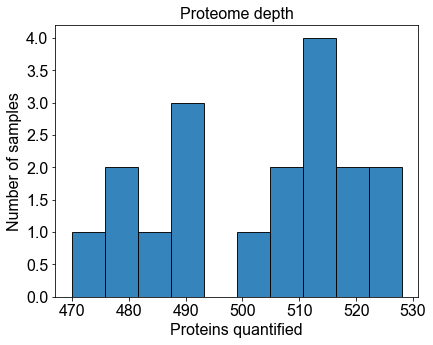

In [18]:

    plt.figure(figsize=(6.5, 5))
    plt.rcParams['font.family'] = 'Arial'

    plt.hist(nonzero_count_per_column, bins=10, edgecolor='k', alpha=0.9)

    # Set the font size for individual elements
    plt.title('Proteome depth', fontsize=16)
    plt.xlabel('Proteins quantified', fontsize=16)
    plt.ylabel('Number of samples', fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Show plot
    plt.show()

In [19]:
tt = df_pro.replace(0,np.nan).T

In [20]:
tt.dropna()

,zoDIAq-file_DUAL_macro_7_corrected_fullOutput,zoDIAq-file_DUAL_macro_8_corrected_fullOutput,zoDIAq-file_DUAL_macro_9_corrected_fullOutput,zoDIAq-file_DUAL_macro_10_corrected_fullOutput,zoDIAq-file_DUAL_macro_11_corrected_fullOutput,zoDIAq-file_DUAL_macro_12_corrected_fullOutput,zoDIAq-file_DUAL_macro_13_corrected_fullOutput,zoDIAq-file_DUAL_macro_14_corrected_fullOutput,zoDIAq-file_DUAL_macro_15_corrected_fullOutput,zoDIAq-file_DUAL_macro_16_corrected_fullOutput,zoDIAq-file_DUAL_macro_17_corrected_fullOutput,zoDIAq-file_DUAL_macro_18_corrected_fullOutput,zoDIAq-file_DUAL_macro_1_corrected_fullOutput,zoDIAq-file_DUAL_macro_2_corrected_fullOutput,zoDIAq-file_DUAL_macro_3_corrected_fullOutput,zoDIAq-file_DUAL_macro_4_corrected_fullOutput,zoDIAq-file_DUAL_macro_5_corrected_fullOutput,zoDIAq-file_DUAL_macro_6_corrected_fullOutput
1/sp|O08529|CAN2_MOUSE,28694.901990,38654.282647,30641.383756,31200.041968,36561.684853,46708.177665,28736.904978,40426.906715,52944.412570,56950.087771,49042.440141,59214.500923,53367.197014,52627.309060,62530.344882,55673.492395,74392.186512,62664.331788
1/sp|O08553|DPYL2_MOUSE,101480.269691,116606.278207,98734.153731,95021.037537,123537.021897,137312.578001,105325.060914,132043.165156,139791.905610,175062.318085,159559.491139,139937.504616,153667.089677,148798.678005,159969.904606,151822.960213,192402.965788,167343.258038
1/sp|O08749|DLDH_MOUSE,23325.380038,32833.845952,24486.888001,27988.962660,26970.599946,33086.919417,21581.192767,32031.687507,33239.460577,32799.880143,33482.500829,33408.526483,25606.265801,34543.166766,27026.094816,30326.112461,30075.278625,26220.600777
1/sp|O09159|MA2B1_MOUSE,38449.279562,54248.849695,36732.530235,38319.952043,45124.202535,51738.126836,44934.847754,48460.822281,64303.891127,63036.882015,59096.472793,55378.639396,42129.507918,62533.082400,62752.579496,57887.013821,58422.058920,60242.294131
1/sp|O35129|PHB2_MOUSE,70566.410695,95952.646033,56610.970535,78572.518819,63347.509381,95452.285162,77729.278347,107271.590851,127929.111945,138735.339891,114838.314883,122565.574666,79677.944625,96005.621554,93441.177281,100545.106559,110419.865127,100358.410448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4/sp|Q6ZWN5|RS9_MOUSE/tr|D3YWH9|D3YWH9_MOUSE/tr|F7CJS8|F7CJS8_MOUSE/tr|Q9CXW7|Q9CXW7_MOUSE,143872.332957,174566.863754,163854.109238,125099.581031,133706.429209,216699.960678,111828.350718,176395.937519,171756.500202,210276.855935,166576.276811,222316.840638,179958.622778,183611.940302,189195.210551,181417.213763,194640.668569,162797.874514
5/sp|P05555|ITAM_MOUSE/tr|E9Q5K8|E9Q5K8_MOUSE/tr|E9Q604|E9Q604_MOUSE/tr|G5E8F1|G5E8F1_MOUSE/tr|Q3U1U4|Q3U1U4_MOUSE,57537.369584,68271.652913,55505.053244,55225.855882,52170.997862,78248.093269,63160.584478,78357.204987,101988.710838,100315.935482,90253.955448,90721.071114,81576.693570,91451.114008,100611.321031,79968.139433,109198.761851,98389.888650
5/sp|P46638|RB11B_MOUSE/sp|P62492|RB11A_MOUSE/tr|E9Q3P9|E9Q3P9_MOUSE/tr|F8WGS1|F8WGS1_MOUSE/tr|G3UY29|G3UY29_MOUSE,89810.322797,143292.675859,99511.028692,95670.226027,98998.613356,124782.776287,90805.360502,134327.669246,159102.595214,173381.004545,139807.091648,146205.434395,128882.869532,134546.126069,142814.715129,130047.397997,145008.873699,122360.418511
5/sp|Q61207|SAP_MOUSE/tr|E9PZ00|E9PZ00_MOUSE/tr|J3QPG5|J3QPG5_MOUSE/tr|K3W4L3|K3W4L3_MOUSE/tr|Q8BFQ1|Q8BFQ1_MOUSE,283513.334074,435207.562242,334381.428732,449049.707989,245161.790354,468665.416717,471566.272599,617070.577493,765755.051264,706824.748111,716500.082019,724729.657238,396960.082514,613836.860859,606111.868844,557460.434270,683704.129803,598913.991386


In [21]:
df_pro=df_pro.iloc[:,:19]
df_pro.set_index('Unnamed: 0',inplace=True)
df_pro

KeyError: "None of ['Unnamed: 0'] are in the columns"

In [5]:
dfpro_log2=np.log2(df_pro)
#dfpro_log2=df_pro
dfpro_log2

,:/yuming/2023/20230309/mzmxl/DUAL_macro_1_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_3.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_4.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_5.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_6.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_7.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_8.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_9.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_10.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_11.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_12.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_13.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_14.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_15.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_16.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_17.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_18.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE,16.399950,16.402934,16.113595,16.837545,17.026636,16.534697,16.393194,16.371245,16.354365,15.883579,15.922663,16.231280,16.644774,16.989237,17.253884,17.644492,17.348647,16.227502
1/sp|P57746|VATD_MOUSE,16.190510,15.968620,16.225165,16.027881,16.432083,16.259936,15.421721,16.141347,15.311970,15.644375,15.277759,16.194294,15.233795,15.142383,17.018270,16.163593,16.234630,16.261301
7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUSE/tr|A0A0G2JEP8|A0A0G2JEP8_MOUSE/tr|A0A0A6YXF6|A0A0A6YXF6_MOUSE/tr|A0A0A6YWJ1|A0A0A6YWJ1_MOUSE/sp|Q9QUI0|RHOA_MOUSE/sp|Q62159|RHOC_MOUSE,17.385758,17.655849,17.427062,17.492805,17.674827,17.467476,16.778647,17.271330,16.973557,17.021470,16.310192,17.213915,17.007867,17.254462,17.535523,17.581042,17.443637,17.452638
3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUSE/sp|Q9WV32|ARC1B_MOUSE,17.259463,17.471313,17.528638,17.607480,17.714243,17.631455,17.056227,17.233256,16.981391,16.757766,16.968896,17.371931,16.838707,17.326323,17.449731,17.509912,17.421140,17.459132
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,19.589614,19.773099,20.026399,19.559832,20.094926,19.961758,18.320197,19.077785,18.467680,18.893309,18.895147,19.433903,18.844159,19.316957,19.433780,19.835651,19.661653,19.693370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE,16.861288,16.826201,17.163062,18.270457,17.307748,17.303681,17.026686,15.986836,17.012272,16.357780,15.880651,16.767688,16.380666,17.887399,17.672286,16.964786,18.144445,17.146467
6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUSE/tr|E9Q1F2|E9Q1F2_MOUSE/sp|Q8BFZ3|ACTBL_MOUSE/sp|P63260|ACTG_MOUSE/sp|P60710|ACTB_MOUSE,22.251754,22.340304,21.943389,22.558105,22.627712,22.358086,21.955797,21.922201,21.746604,21.768573,21.495536,21.651425,22.055816,22.122479,22.387702,22.596671,22.221325,22.299007
8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUSE/tr|H3BKH6|H3BKH6_MOUSE/tr|H3BK43|H3BK43_MOUSE/tr|H3BJP2|H3BJP2_MOUSE/tr|H3BJL6|H3BJL6_MOUSE/tr|H3BJC6|H3BJC6_MOUSE/sp|Q9R0P3|ESTD_MOUSE,16.619857,17.116137,16.677471,16.953533,17.064501,16.778456,16.013750,16.304717,15.982324,16.040963,16.291141,16.134549,16.338809,16.612691,17.020354,17.126816,16.713129,16.919846


In [6]:
# apply standard scaler to the new dataframe 
ss = StandardScaler() 
df_ss = ss.fit_transform(dfpro_log2)
dfpro_std=pd.DataFrame(df_ss,index=dfpro_log2.index,columns=dfpro_log2.columns)
dfpro_std

,:/yuming/2023/20230309/mzmxl/DUAL_macro_1_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_3.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_4.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_5.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_6.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_7.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_8.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_9.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_10.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_11.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_12.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_13.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_14.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_15.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_16.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_17.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_18.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE,-0.435959,-0.504249,-0.713103,-0.288589,-0.249383,-0.497782,-0.221553,-0.429420,-0.253149,-0.558492,-0.584283,-0.608658,-0.099384,-0.091143,-0.048570,0.117224,0.005506,-0.670277
1/sp|P57746|VATD_MOUSE,-0.558984,-0.758277,-0.646898,-0.778761,-0.600859,-0.660326,-0.816983,-0.567223,-0.881224,-0.702876,-0.982467,-0.630961,-0.953768,-1.192340,-0.188022,-0.760752,-0.654747,-0.650241
7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUSE/tr|A0A0G2JEP8|A0A0G2JEP8_MOUSE/tr|A0A0A6YXF6|A0A0A6YXF6_MOUSE/tr|A0A0A6YWJ1|A0A0A6YWJ1_MOUSE/sp|Q9QUI0|RHOA_MOUSE/sp|Q62159|RHOC_MOUSE,0.143104,0.228576,0.066303,0.108106,0.133802,0.054034,0.014696,0.110098,0.119933,0.128343,-0.345010,-0.016116,0.120478,0.066999,0.118123,0.079607,0.061805,0.055969
3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUSE/sp|Q9WV32|ARC1B_MOUSE,0.068919,0.120641,0.126577,0.177530,0.157103,0.151041,0.184829,0.087276,0.124653,-0.030830,0.061694,0.079169,0.018047,0.109846,0.067345,0.037437,0.048471,0.059818
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,1.437649,1.466945,1.608738,1.359486,1.564471,1.529609,0.959534,1.192901,1.020188,1.258190,1.251021,1.322565,1.232400,1.296773,1.241640,1.416292,1.376372,1.384247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE,-0.164969,-0.256682,-0.090354,0.578897,-0.083201,-0.042865,0.166723,-0.659838,0.143260,-0.272263,-0.610223,-0.285197,-0.259308,0.444391,0.199069,-0.285751,0.477157,-0.125526
6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUSE/tr|E9Q1F2|E9Q1F2_MOUSE/sp|Q8BFZ3|ACTBL_MOUSE/sp|P63260|ACTG_MOUSE/sp|P60710|ACTB_MOUSE,3.001389,2.968492,2.746272,3.174644,3.061755,2.947235,3.187844,2.897867,2.995840,2.993707,2.856582,2.659760,3.177141,2.969581,2.989971,3.053210,2.893431,2.928837
8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUSE/tr|H3BKH6|H3BKH6_MOUSE/tr|H3BK43|H3BK43_MOUSE/tr|H3BJP2|H3BJP2_MOUSE/tr|H3BJL6|H3BJL6_MOUSE/tr|H3BJC6|H3BJC6_MOUSE/sp|Q9R0P3|ESTD_MOUSE,-0.306785,-0.087099,-0.378501,-0.218370,-0.226999,-0.353579,-0.454120,-0.469297,-0.477315,-0.463494,-0.356773,-0.666988,-0.284654,-0.315661,-0.186789,-0.189689,-0.371151,-0.259864


In [9]:
# function for oneway_ANOVA analysis 
def oneway_ANOVA(result=dfpro_std):
    pval=[]
    for i in range(len(result)):
        aa=result.iloc[i,:6].tolist()
        bb=result.iloc[i,6:12].tolist()
        cc=result.iloc[i,12:18].tolist()     
        p_value=f_oneway(aa,bb,cc)[1]
        pval.append([i,p_value])
        fl = pd.DataFrame(pval)
        fl.columns = ['number', 'p_value']
    return(fl)

In [20]:
# apply anova to all proteins, and calculate p VALUES
# here is the point, which dataframe should be choosen, the raw one after log2, or the normalized one? 


dfpro_pval=oneway_ANOVA(result=dfpro_log2)
dfpro_pval['index_name']=dfpro_std.index.values.tolist()
dfpro_pval

,number,p_value,index_name
0,0,0.006371,2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE
1,1,0.199824,1/sp|P57746|VATD_MOUSE
2,2,0.002324,7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUS...
3,3,0.005346,3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUS...
4,4,0.000533,2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE
...,...,...,...
828,828,0.034590,2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE
829,829,0.000277,6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUS...
830,830,0.000056,8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUS...
831,831,0.009732,3/tr|D3Z7J9|D3Z7J9_MOUSE/tr|D3Z2F2|D3Z2F2_MOUS...


In [12]:
df_pro['p_val']=dfpro_pval["p_value"].tolist()
df_pro

,:/yuming/2023/20230309/mzmxl/DUAL_macro_1_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_3.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_4.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_5.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_6.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_7.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_8.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_9.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_10.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_11.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_12.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_13.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_14.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_15.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_16.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_17.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_18.mzXML,p_val
Unnamed: 0,,,,,,,,,,,,,,,,,,,
2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE,8.647227e+04,8.665131e+04,7.090476e+04,1.171133e+05,1.335144e+05,9.493793e+04,8.606827e+04,8.476876e+04,8.378274e+04,6.045521e+04,6.211537e+04,7.693112e+04,1.024652e+05,1.300978e+05,1.562920e+05,2.048902e+05,1.669026e+05,7.672996e+04,0.006371
1/sp|P57746|VATD_MOUSE,7.478752e+04,6.412592e+04,7.660576e+04,6.681485e+04,8.841990e+04,7.847448e+04,4.389353e+04,7.228191e+04,4.067825e+04,5.121841e+04,3.972499e+04,7.498394e+04,3.853268e+04,3.616693e+04,1.327424e+05,7.340512e+04,7.710996e+04,7.854878e+04,0.199824
7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUSE/tr|A0A0G2JEP8|A0A0G2JEP8_MOUSE/tr|A0A0A6YXF6|A0A0A6YXF6_MOUSE/tr|A0A0A6YWJ1|A0A0A6YWJ1_MOUSE/sp|Q9QUI0|RHOA_MOUSE/sp|Q62159|RHOC_MOUSE,1.712516e+05,2.065095e+05,1.762254e+05,1.844417e+05,2.092440e+05,1.812317e+05,1.124284e+05,1.581934e+05,1.286915e+05,1.330372e+05,8.125630e+04,1.520215e+05,1.317887e+05,1.563546e+05,1.899847e+05,1.960745e+05,1.782617e+05,1.793773e+05,0.002324
3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUSE/sp|Q9WV32|ARC1B_MOUSE,1.568975e+05,1.817143e+05,1.890801e+05,1.997008e+05,2.150396e+05,2.030470e+05,1.362812e+05,1.540732e+05,1.293922e+05,1.108129e+05,1.282764e+05,1.696181e+05,1.172076e+05,1.643398e+05,1.790163e+05,1.866418e+05,1.755034e+05,1.801865e+05,0.005346
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,7.889718e+05,8.959751e+05,1.067940e+06,7.728515e+05,1.119890e+06,1.021146e+06,3.272871e+05,5.533315e+05,3.625147e+05,4.869146e+05,4.875352e+05,7.082517e+05,4.706057e+05,6.531056e+05,7.081915e+05,9.356772e+05,8.293681e+05,8.478030e+05,0.000533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE,1.190566e+05,1.161960e+05,1.467562e+05,3.161955e+05,1.622375e+05,1.617808e+05,1.335190e+05,6.494072e+04,1.321917e+05,8.398126e+04,6.033263e+04,1.115776e+05,8.532413e+04,2.424619e+05,2.088759e+05,1.279114e+05,2.897492e+05,1.450777e+05,0.034590
6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUSE/tr|E9Q1F2|E9Q1F2_MOUSE/sp|Q8BFZ3|ACTBL_MOUSE/sp|P63260|ACTG_MOUSE/sp|P60710|ACTB_MOUSE,4.993965e+06,5.310088e+06,4.032909e+06,6.175417e+06,6.480673e+06,5.375942e+06,4.067744e+06,3.974113e+06,3.518682e+06,3.572674e+06,2.956658e+06,3.294037e+06,4.359757e+06,4.565934e+06,5.487439e+06,6.342721e+06,4.889734e+06,5.160241e+06,0.000277
8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUSE/tr|H3BKH6|H3BKH6_MOUSE/tr|H3BK43|H3BK43_MOUSE/tr|H3BJP2|H3BJP2_MOUSE/tr|H3BJL6|H3BJL6_MOUSE/tr|H3BJC6|H3BJC6_MOUSE/sp|Q9R0P3|ESTD_MOUSE,1.007107e+05,1.420596e+05,1.048139e+05,1.269176e+05,1.370650e+05,1.124135e+05,6.616359e+04,8.094854e+04,6.473796e+04,6.742346e+04,8.019036e+04,7.194210e+04,8.288418e+04,1.002117e+05,1.329343e+05,1.431151e+05,1.074368e+05,1.239884e+05,0.000056


In [13]:
df_pro.to_csv(r'E:\\project7_SMAD\\raw_pvalue.csv')

In [14]:
len([item for item in dfpro_pval['p_value'].tolist() if item <0.05])

415

In [15]:
FDR_res=statsmodels.stats.multitest.fdrcorrection(dfpro_pval['p_value'].tolist(), alpha=0.05, method='indep', is_sorted=False)[0]

In [16]:
# calculate the pvalues < 0.01 after FDR correction 

yuyu=[]
for item in range(len(FDR_res)):
    if FDR_res[item]== True:
        yuyu.append(item)
len(yuyu)

297

In [19]:
# locate the significant proteins from df_pval dataframe, aiming to find the protein names out 
sig_pro=dfpro_pval.loc[yuyu]
sig_pro

,number,p_value,index_name
0,0,0.006371,2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE
2,2,0.002324,7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUS...
3,3,0.005346,3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUS...
4,4,0.000533,2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE
12,12,0.001030,1/sp|Q9DBJ1|PGAM1_MOUSE
...,...,...,...
826,826,0.001284,1/sp|Q9WTI7|MYO1C_MOUSE
829,829,0.000277,6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUS...
830,830,0.000056,8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUS...
831,831,0.009732,3/tr|D3Z7J9|D3Z7J9_MOUSE/tr|D3Z2F2|D3Z2F2_MOUS...


In [13]:
dfpro_sig=dfpro_std.loc[sig_pro['index_name']]
dfpro_sig

,:/yuming/2023/20230309/mzmxl/DUAL_macro_1_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_3.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_4.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_5.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_6.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_7.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_8.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_9.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_10.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_11.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_12.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_13.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_14.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_15.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_16.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_17.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_18.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,1.437649,1.466945,1.608738,1.359486,1.564471,1.529609,0.959534,1.192901,1.020188,1.258190,1.251021,1.322565,1.232400,1.296773,1.241640,1.416292,1.376372,1.384247
9/tr|G5E846|G5E846_MOUSE/tr|G3X981|G3X981_MOUSE/tr|A0A2R8W6R6|A0A2R8W6R6_MOUSE/tr|A0A0A6YWC8|A0A0A6YWC8_MOUSE/sp|Q9DCV7|K2C7_MOUSE/sp|P31001|DESM_MOUSE/sp|P20152|VIME_MOUSE/sp|P15331|PERI_MOUSE/sp|P11679|K2C8_MOUSE,0.906742,0.843573,1.043151,0.815198,0.845599,0.886500,1.083225,1.072578,1.063664,0.962612,1.202520,1.048992,0.923162,0.952388,1.015176,0.995510,0.956871,0.901371
2/tr|Q8BG13|Q8BG13_MOUSE/sp|O89086|RBM3_MOUSE,-0.719458,-0.761271,-0.878551,-0.915999,-0.830679,-0.840486,-0.660752,-0.634883,-0.458612,-0.783513,-0.665388,-0.666357,-0.846966,-0.900888,-0.843658,-0.750296,-0.750695,-0.775862
1/sp|Q9DBJ1|PGAM1_MOUSE,0.602574,0.389774,0.573610,0.548770,0.699768,0.407984,0.214738,0.176859,-0.033578,0.156149,0.538545,0.321998,0.316344,0.355872,0.400626,0.436149,0.422369,0.571018
2/tr|B8JKK2|B8JKK2_MOUSE/sp|Q9CZM2|RL15_MOUSE,0.591943,0.511549,0.551339,0.543894,0.590697,0.567305,0.700997,0.772576,0.728256,0.604202,0.817213,0.792440,0.607435,0.665748,0.749815,0.659165,0.617457,0.651015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,1.369202,1.540906,1.332546,1.433370,1.390313,1.342238,1.029653,0.943324,1.006160,1.257495,1.132416,1.061423,1.308767,1.311783,1.234444,1.294335,1.203677,1.352024
1/sp|P40142|TKT_MOUSE,-0.462386,-0.359567,-0.421986,-0.473130,-0.323738,-0.408570,-0.728525,-0.807261,-0.797189,-0.825181,-1.175585,-0.719950,-0.582371,-0.610814,-0.426275,-0.349936,-0.425012,-0.388796
1/sp|Q8K1T1|LRC25_MOUSE,-1.270516,-1.298704,-1.275685,-1.131195,-1.096890,-1.018397,-0.722453,-0.819529,-0.804773,-0.683976,-0.635522,-0.842141,-1.025922,-1.010447,-0.857632,-0.877458,-1.210406,-1.206712


In [88]:
k=[item.split("|")[1] for item in dfpro_sig.index]
dfk=pd.DataFrame(k)
dfk.to_csv(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_sigpro_224_GeneIDs.csv')

In [129]:
dfpro_sig.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_sigpro_224.xlsx')

In [14]:
treatment=['Con']*6+['LPS']*6+['IL_4']*6
PCA_pro_sig=dfpro_sig.T

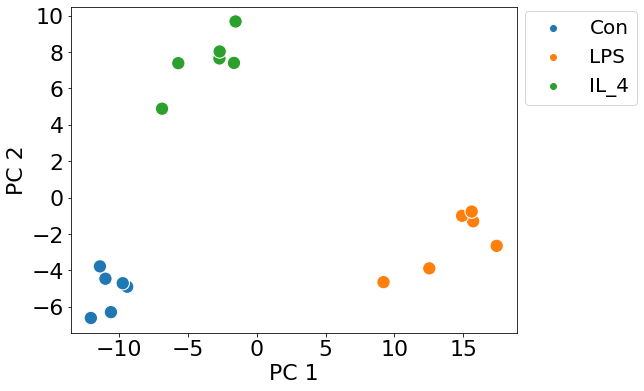

In [15]:
# set the data soucrce
df =PCA_pro_sig

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# perform PCA with 2 principal components
pca = PCA(n_components=2)
pca.fit(X_scaled)

# transform the features to the new space
X_pca = pca.transform(X_scaled)

# create a new dataframe with the principal components and target variable
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = treatment

# plot the results
import seaborn as sns
plt.figure(figsize=(8, 6), edgecolor='#04253a')
sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca, s=180)
plt.yticks(fontsize=22)
plt.xticks(fontsize=22)
plt.xlabel('PC 1', fontsize=22)
plt.ylabel('PC 2', fontsize=22)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.2,fontsize=20)

In [16]:
dfpro_std2=dfpro_std

In [17]:
# 按行进行标准归一化
scaler=StandardScaler()
proname=dfpro_std2.T.columns
k=dfpro_std2.T
dfdf_pro=ss.fit_transform(k)
# 按行进行标准化后的 dataframe
dfpro_stdbyrow=pd.DataFrame(dfdf_pro.T,index=dfpro_std2.index,columns=dfpro_std2.columns)
dfpro_stdbyrow

,:/yuming/2023/20230309/mzmxl/DUAL_macro_1_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_2.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_3.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_4.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_5.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_6.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_7.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_8.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_9.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_10.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_11.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_12.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_13.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_14.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_15.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_16.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_17.mzXML,:/yuming/2023/20230309/mzmxl/DUAL_macro_18.mzXML
Unnamed: 0,,,,,,,,,,,,,,,,,,
2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE,-0.392376,-0.673446,-1.533060,0.214175,0.375540,-0.646833,0.490084,-0.365464,0.360041,-0.896702,-1.002856,-1.103180,0.992914,1.026834,1.202057,1.884440,1.424625,-1.356793
1/sp|P57746|VATD_MOUSE,0.789887,-0.179176,0.362405,-0.278779,0.586266,0.297108,-0.464635,0.749825,-0.777008,0.090210,-1.269300,0.439898,-1.129753,-2.289809,2.593689,-0.191213,0.324239,0.346147
7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUSE/tr|A0A0G2JEP8|A0A0G2JEP8_MOUSE/tr|A0A0A6YXF6|A0A0A6YXF6_MOUSE/tr|A0A0A6YWJ1|A0A0A6YWJ1_MOUSE/sp|Q9QUI0|RHOA_MOUSE/sp|Q62159|RHOC_MOUSE,0.649779,1.403094,-0.027127,0.341315,0.567790,-0.135261,-0.481971,0.358868,0.445554,0.519675,-3.652307,-0.753538,0.450357,-0.020988,0.429601,0.090136,-0.066771,-0.118208
3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUSE/sp|Q9WV32|ARC1B_MOUSE,-0.408263,0.520993,0.627641,1.543076,1.176074,1.067154,1.674200,-0.078448,0.593071,-2.200362,-0.538062,-0.224097,-1.322224,0.327050,-0.436526,-0.973875,-0.775633,-0.571768
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,0.654096,0.830200,1.682530,0.184251,1.416435,1.206876,-2.219906,-0.817111,-1.855310,-0.424651,-0.467744,-0.037686,-0.579678,-0.192725,-0.524137,0.525714,0.285755,0.333091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE,-0.305936,-0.580006,-0.082959,1.917007,-0.061582,0.058956,0.685279,-1.784784,0.615164,-0.626569,-1.636515,-0.665221,-0.587855,1.515052,0.781941,-0.666877,1.612971,-0.188066
6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUSE/tr|E9Q1F2|E9Q1F2_MOUSE/sp|Q8BFZ3|ACTBL_MOUSE/sp|P63260|ACTG_MOUSE/sp|P60710|ACTB_MOUSE,0.216411,-0.029345,-1.689417,1.510694,0.667370,-0.188139,1.609305,-0.556940,0.174955,0.159026,-0.865352,-2.335691,1.529343,-0.021207,0.131110,0.603532,-0.590075,-0.325581
8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUSE/tr|H3BKH6|H3BKH6_MOUSE/tr|H3BK43|H3BK43_MOUSE/tr|H3BJP2|H3BJP2_MOUSE/tr|H3BJL6|H3BJL6_MOUSE/tr|H3BJC6|H3BJC6_MOUSE/sp|Q9R0P3|ESTD_MOUSE,0.226269,1.868020,-0.309679,0.887011,0.822525,-0.123427,-0.874789,-0.988213,-1.048131,-0.944845,-0.147298,-2.465591,0.391663,0.159942,1.123022,1.101351,-0.254749,0.576919


In [18]:
#calculate the mean value of proteins from 6 repeats in each treatment 
con=dfpro_stdbyrow.iloc[:,:6].mean(axis=1).tolist()
lps=dfpro_stdbyrow.iloc[:,6:12].mean(axis=1).tolist()
IL_4=dfpro_stdbyrow.iloc[:,12:18].mean(axis=1).tolist()
newdict={'Con':con,'LPS':lps,'IL_4':IL_4}

dfpro_mean=pd.DataFrame.from_dict(newdict)
dfpro_mean.index=dfpro_stdbyrow.index
dfpro_mean

,Con,LPS,IL_4
Unnamed: 0,,,
2/tr|B0V2N5|B0V2N5_MOUSE/sp|P07356|ANXA2_MOUSE,-0.442667,-0.419680,0.862346
1/sp|P57746|VATD_MOUSE,0.262952,-0.205168,-0.057784
7/tr|Q9CR99|Q9CR99_MOUSE/tr|H3BL56|H3BL56_MOUSE/tr|A0A0G2JEP8|A0A0G2JEP8_MOUSE/tr|A0A0A6YXF6|A0A0A6YXF6_MOUSE/tr|A0A0A6YWJ1|A0A0A6YWJ1_MOUSE/sp|Q9QUI0|RHOA_MOUSE/sp|Q62159|RHOC_MOUSE,0.466598,-0.593953,0.127355
3/tr|Q91Z25|Q91Z25_MOUSE/tr|F6THG2|F6THG2_MOUSE/sp|Q9WV32|ARC1B_MOUSE,0.754446,-0.128950,-0.625496
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,0.995731,-0.970401,-0.025330
...,...,...,...
2/tr|F6WA09|F6WA09_MOUSE/sp|P62259|1433E_MOUSE,0.157580,-0.568774,0.411194
6/tr|G3UZ07|G3UZ07_MOUSE/tr|E9Q5F4|E9Q5F4_MOUSE/tr|E9Q1F2|E9Q1F2_MOUSE/sp|Q8BFZ3|ACTBL_MOUSE/sp|P63260|ACTG_MOUSE/sp|P60710|ACTB_MOUSE,0.081263,-0.302450,0.221187
8/tr|H3BLJ9|H3BLJ9_MOUSE/tr|H3BL99|H3BL99_MOUSE/tr|H3BKH6|H3BKH6_MOUSE/tr|H3BK43|H3BK43_MOUSE/tr|H3BJP2|H3BJP2_MOUSE/tr|H3BJL6|H3BJL6_MOUSE/tr|H3BJC6|H3BJC6_MOUSE/sp|Q9R0P3|ESTD_MOUSE,0.561786,-1.078144,0.516358


In [19]:
sigpro_stdrow=dfpro_mean.loc[sig_pro['index_name']]

In [20]:
#sigpro_stdrow

In [37]:
def optimise_k_means(data,max_k):
    means=[]
    inertias=[]
    for k in range(1,max_k):
        kmeans=KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
    fig=plt.subplots(figsize=(10,5))
    plt.plot(means,inertias)
    plt.xlabel('number of clusters')
    plt.ylabel('inertia')
    plt.show()

In [24]:
#optimise_k_means(sigpro_stdrow,10)

In [21]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(sigpro_stdrow[['Con','LPS','IL_4']])

sigpro_stdrow['kmeans']=kmeans.labels_
sigpro_stdrow

,Con,LPS,IL_4,kmeans
Unnamed: 0,,,,
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,0.995731,-0.970401,-0.025330,3
9/tr|G5E846|G5E846_MOUSE/tr|G3X981|G3X981_MOUSE/tr|A0A2R8W6R6|A0A2R8W6R6_MOUSE/tr|A0A0A6YWC8|A0A0A6YWC8_MOUSE/sp|Q9DCV7|K2C7_MOUSE/sp|P31001|DESM_MOUSE/sp|P20152|VIME_MOUSE/sp|P15331|PERI_MOUSE/sp|P11679|K2C8_MOUSE,-0.845362,1.006575,-0.161213,1
2/tr|Q8BG13|Q8BG13_MOUSE/sp|O89086|RBM3_MOUSE,-0.579152,1.040851,-0.461699,1
1/sp|Q9DBJ1|PGAM1_MOUSE,0.794994,-0.921173,0.126179,3
2/tr|B8JKK2|B8JKK2_MOUSE/sp|Q9CZM2|RL15_MOUSE,-1.037064,0.956212,0.080852,2
...,...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694,3
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966,3
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983,1


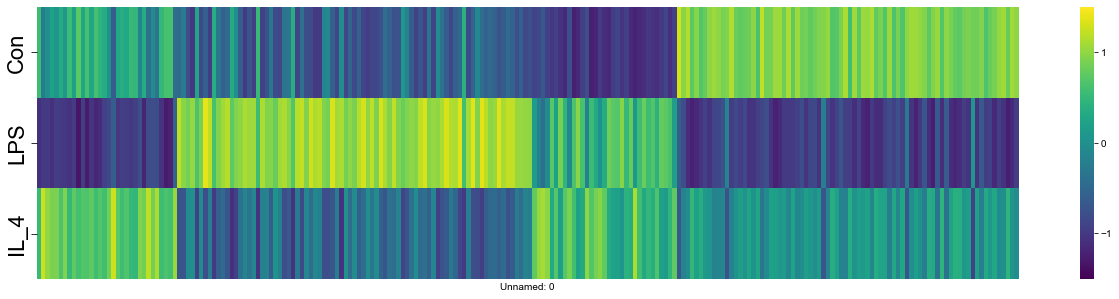

In [49]:
# plot heatmap for significant metabolites
df_df=sigpro_stdrow
dfaa=df_df.sort_values(by='kmeans')
df_bb=dfaa.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(22,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 1, 'ticks': [-2, -1, 0, 1, 2]})
plt.xticks([])
plt.yticks()
plt.tick_params(axis='y',length=6)
plt.yticks(rotation=90)
plt.yticks(fontsize=22)
plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\sigpro_heatmap.svg',dpi=1000,bbox_inches='tight')

In [22]:
x=['Con','LPS','IL_4']

# take different cluster protein names out
#sig_cluster4=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==4]
sig_cluster3=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==3]
sig_cluster2=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==2]
sig_cluster1=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==1]
sig_cluster0=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==0]

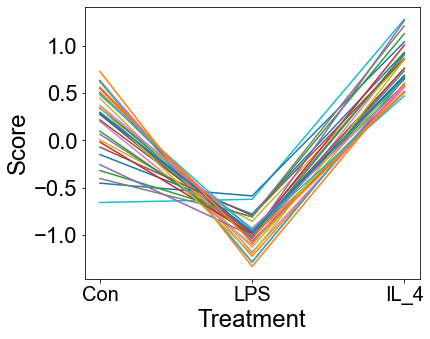

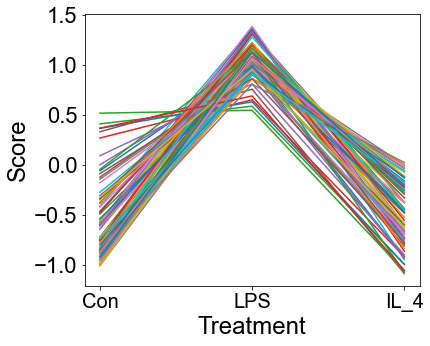

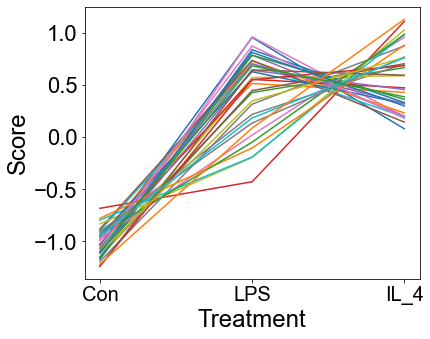

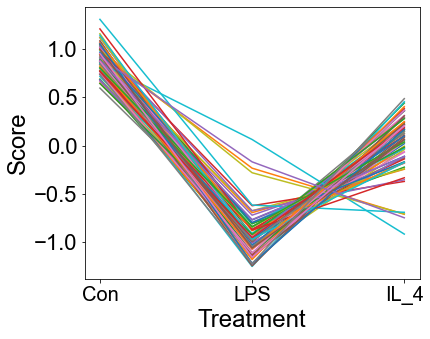

In [24]:
import matplotlib.pyplot as plt

# Create a dictionary of cluster names and corresponding data
cluster_data = {'sigpro_Cluster 1': sigpro_stdrow.loc[list(sig_cluster0.index)],
                'sigpro_Cluster 2': sigpro_stdrow.loc[list(sig_cluster1.index)],
                'sigpro_Cluster 3': sigpro_stdrow.loc[list(sig_cluster2.index)],
                'sigpro_Cluster 4': sigpro_stdrow.loc[list(sig_cluster3.index)],}
                #'Cluster 5': sigpro_stdrow.loc[list(sig_cluster4.index)]}

# Loop over the dictionary items to plot the data for each cluster
for title, data in cluster_data.items():
    plt.figure(figsize=(6, 5), edgecolor='#04253a')
    plt.rcParams['font.family'] = 'Arial'
    for i in range(len(data)):
        plt.plot(x, data.iloc[i, :3])  
    #plt.title(title, fontsize=24)
    plt.xlabel('Treatment', fontsize=24)
    plt.ylabel('Score', fontsize=24)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=22)
    plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\{}.svg'.format(title),dpi=800,bbox_inches='tight')
    plt.show()

# metabolome analysis of macrophage starts from here

In [4]:
# import raw data of macrophage metabolome 

df_meta=pd.read_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\raw_data\\macro_metabolites_raw.xlsx')

In [12]:
df_meta=df_meta.drop_duplicates(subset=['mz'],keep='first')
df_meta.set_index('mz',inplace=True)
df_meta

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz,,,,,,,,,,,,,,,,,,
103.05445,19080.0,17900.0,22080.0,21070.0,20310.0,26800.0,20440.0,20940.0,18890.0,22230.0,24300.0,23620.0,26850.0,31430.0,43110.0,37800.0,45120.0,36570.0
106.08668,10790.0,8605.0,11910.0,20410.0,10720.0,18590.0,22860.0,28620.0,17400.0,14570.0,18470.0,18960.0,9871.0,8872.0,17070.0,13110.0,15140.0,14900.0
114.09163,26180.0,30400.0,34120.0,52020.0,35490.0,63800.0,35360.0,33240.0,40230.0,44030.0,60860.0,61110.0,30090.0,28940.0,68400.0,61040.0,59490.0,54470.0
119.04943,6226.0,5279.0,7889.0,6684.0,6524.0,9310.0,5653.0,6031.0,6012.0,6079.0,7931.0,6886.0,8208.0,9324.0,14980.0,13290.0,14360.0,11810.0
120.08104,287200.0,271700.0,343500.0,347100.0,313300.0,422600.0,271400.0,284400.0,248200.0,268900.0,321500.0,318000.0,401100.0,476800.0,664600.0,576500.0,646400.0,616100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015.88826,6693.0,4889.0,6202.0,2281.0,11730.0,1777.0,2303.0,3114.0,1172.0,6488.0,1526.0,708.8,3044.0,1660.0,1623.0,4697.0,4228.0,3834.0
1002.20926,7756.0,1440.0,3469.0,7575.0,3125.0,9785.0,5053.0,7468.0,6951.0,3320.0,6731.0,2044.0,6482.0,1226.0,1678.0,2603.0,2420.0,3609.0
1015.66946,5377.0,5453.0,4331.0,2685.0,3369.0,7853.0,1730.0,360.7,1374.0,7685.0,1176.0,4480.0,5545.0,4050.0,2303.0,3851.0,2821.0,3807.0


In [13]:
dfmeta_log2=np.log2(df_meta)
#dfpro_log2=df_pro
dfmeta_log2

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz,,,,,,,,,,,,,,,,,,
103.05445,14.219774,14.127672,14.430453,14.362903,14.309903,14.709945,14.319108,14.353974,14.205335,14.440220,14.568669,14.527721,14.712634,14.939855,15.395735,15.206099,15.461479,15.158373
106.08668,13.397407,13.070959,13.539886,14.316989,13.388017,14.182239,14.480538,14.804736,14.086800,13.830713,14.172896,14.210671,13.268981,13.115044,14.059175,13.678380,13.886078,13.863025
114.09163,14.676177,14.891784,15.058330,15.666779,15.115125,15.961269,15.109831,15.020633,15.295984,15.426199,15.893207,15.899121,14.876996,14.820777,16.061709,15.897467,15.860360,15.733174
119.04943,12.604090,12.366049,12.945627,12.706496,12.671541,13.184565,12.464801,12.558182,12.553629,12.569618,12.953287,12.749450,13.002815,13.186733,13.870750,13.698053,13.809768,13.527721
120.08104,18.131696,18.051655,18.389951,18.404992,18.257185,18.688933,18.050061,18.117562,17.921144,18.036710,18.294459,18.278667,18.613602,18.863025,19.342127,19.136961,19.302068,19.232805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015.88826,12.708437,12.255324,12.598518,11.155451,13.517915,10.795228,11.169299,11.604553,10.194757,12.663558,10.575539,9.469235,11.571753,10.696968,10.664447,12.197524,12.045760,11.904635
1002.20926,12.921097,10.491853,11.760304,12.887030,11.609640,13.256356,12.302924,12.866506,12.763005,11.696968,12.716605,10.997179,12.662223,10.259743,10.712527,11.345960,11.240791,11.817383
1015.66946,12.392586,12.412834,12.080484,11.390706,11.718105,12.939028,10.756556,8.494656,10.424166,12.907830,10.199672,12.129283,12.436972,11.983706,11.169299,11.911017,11.461991,11.894439


In [14]:
#df_meta= df_meta[df_meta >= 4000].dropna()

In [15]:
ss = StandardScaler() 
dfmeta_ss = ss.fit_transform(dfmeta_log2)
dfmeta_std=pd.DataFrame(dfmeta_ss,index=dfmeta_log2.index,columns=dfmeta_log2.columns)

dfmeta_std

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz,,,,,,,,,,,,,,,,,,
103.05445,0.782094,0.717248,0.905932,0.899586,0.781438,1.016370,0.818617,0.902179,0.963046,0.873753,0.920600,0.901648,1.021947,1.226739,1.323378,1.267207,1.270069,1.253887
106.08668,0.370745,0.176076,0.432105,0.875089,0.296394,0.736004,0.896122,1.114649,0.905733,0.552637,0.717490,0.743570,0.269378,0.314319,0.599810,0.428498,0.406611,0.565321
114.09163,1.010388,1.108571,1.239995,1.595257,1.205101,1.681187,1.198254,1.216413,1.490385,1.393211,1.600350,1.585410,1.107628,1.167199,1.683914,1.646765,1.488691,1.559433
119.04943,-0.026074,-0.184928,0.115929,0.015827,-0.080576,0.205948,-0.071661,0.055721,0.164431,-0.111765,0.091589,0.015024,0.130627,0.350165,0.497803,0.439298,0.364787,0.387084
120.08104,2.738846,2.726829,3.012589,3.056203,2.858276,3.130372,2.609899,2.676170,2.759674,2.768546,2.832667,2.771823,3.055500,3.188355,3.459820,3.425230,3.375049,3.419726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015.88826,0.026120,-0.241634,-0.068751,-0.811717,0.364739,-1.063487,-0.693650,-0.393778,-0.976106,-0.062273,-1.128666,-1.620451,-0.615378,-0.894738,-1.237980,-0.384485,-0.602045,-0.475697
1002.20926,0.132493,-1.144757,-0.514724,0.112150,-0.639288,0.244090,-0.149380,0.201052,0.265666,-0.571516,-0.029875,-0.858637,-0.046921,-1.113353,-1.211951,-0.851989,-1.043238,-0.522077
1015.66946,-0.131869,-0.160968,-0.344371,-0.686199,-0.582221,0.075496,-0.891813,-1.859648,-0.865184,0.066420,-1.321560,-0.294184,-0.164344,-0.251358,-0.964671,-0.541775,-0.922001,-0.481117


In [16]:
# calculate the p values of metabolome for different treatments 

dfmeta_pval=oneway_ANOVA(result=dfmeta_std)
dfmeta_pval['index_name']=dfmeta_std.index.values.tolist()
dfmeta_pval

NameError: name 'oneway_ANOVA' is not defined

In [17]:
len([item for item in dfmeta_pval['p_value'].tolist() if item <0.05])

NameError: name 'dfmeta_pval' is not defined

In [18]:
FDR_res_meta=statsmodels.stats.multitest.fdrcorrection(dfmeta_pval['p_value'].tolist(), alpha=0.05, method='indep', is_sorted=False)[0]

NameError: name 'dfmeta_pval' is not defined

In [18]:
# calculate the pvalues < 0.01 after FDR correction 

meta_yuyu=[]
for item in range(len(FDR_res_meta)):
    if FDR_res_meta[item]== True:
        meta_yuyu.append(item)
len(meta_yuyu)

3595

In [19]:
# locate the significant m/z from dfmeta_std dataframe, aiming to find the sig mz names out 

sig_meta=dfmeta_pval.loc[meta_yuyu]
sig_meta

,number,p_value,index_name
0,0,0.000006,103.05445
1,1,0.009796,106.08668
3,3,0.000209,119.04943
4,4,0.000013,120.08104
7,7,0.000056,130.05033
...,...,...,...
9724,9724,0.012922,980.57307
9745,9745,0.009616,978.20677
9771,9771,0.000041,989.48732
9773,9773,0.015519,977.75288


In [20]:
dfmeta_sig=dfmeta_std.loc[sig_meta['index_name']]
dfmeta_sig

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz,,,,,,,,,,,,,,,,,,
103.05445,0.782094,0.717248,0.905932,0.899586,0.781438,1.016370,0.818617,0.902179,0.963046,0.873753,0.920600,0.901648,1.021947,1.226739,1.323378,1.267207,1.270069,1.253887
106.08668,0.370745,0.176076,0.432105,0.875089,0.296394,0.736004,0.896122,1.114649,0.905733,0.552637,0.717490,0.743570,0.269378,0.314319,0.599810,0.428498,0.406611,0.565321
119.04943,-0.026074,-0.184928,0.115929,0.015827,-0.080576,0.205948,-0.071661,0.055721,0.164431,-0.111765,0.091589,0.015024,0.130627,0.350165,0.497803,0.439298,0.364787,0.387084
120.08104,2.738846,2.726829,3.012589,3.056203,2.858276,3.130372,2.609899,2.676170,2.759674,2.768546,2.832667,2.771823,3.055500,3.188355,3.459820,3.425230,3.375049,3.419726
130.05033,0.372748,0.340515,0.439162,0.348682,0.367323,0.503167,0.318634,0.428220,0.486006,0.281611,0.338479,0.392012,0.487941,0.709779,0.562321,0.720723,0.650882,0.635601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980.57307,-0.540794,0.068793,-0.493770,0.143316,-0.877260,0.321157,0.240607,0.538704,0.186697,-0.036247,0.212583,0.260149,-0.526467,-0.238647,-0.007495,-1.713561,-1.126549,-0.520591
978.20677,-0.420587,0.078165,-0.039369,-0.674252,-1.441569,-0.379580,-0.204126,0.124204,-0.306431,-1.071373,-0.636381,-0.954486,-0.762544,-2.002944,-1.315312,-1.455454,-1.658822,-0.998910
989.48732,0.252874,0.625047,0.500504,0.367871,0.311814,0.420047,0.757731,0.765610,0.395999,0.067211,0.398204,0.417531,-0.003857,-0.061141,-0.148898,-0.455903,-0.332682,-0.203728


In [35]:
treatment=['Con']*6+['LPS']*6+['IL_4']*6
PCA_meta_sig=dfmeta_sig.T

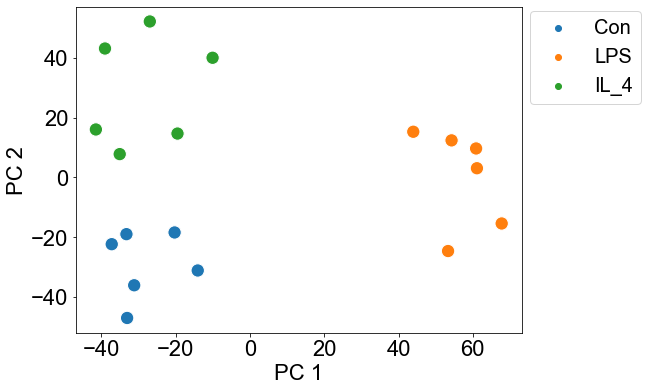

In [36]:
# set the data soucrce
df =PCA_meta_sig
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# perform PCA with 2 principal components
pca = PCA(n_components=2)
pca.fit(X_scaled)

# transform the features to the new space
X_pca = pca.transform(X_scaled)

# create a new dataframe with the principal components and target variable
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = treatment

# plot the results
plt.figure(figsize=(8, 6), edgecolor='#04253a')
sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca, s=180)
plt.yticks(fontsize=22)
plt.xticks(fontsize=22)
plt.xlabel('PC 1', fontsize=22)
plt.ylabel('PC 2', fontsize=22)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.2,fontsize=20)

In [37]:
#K means clustering process of significant metabolite features start here

In [21]:
dfmeta_std2=dfmeta_std

In [22]:
# 按行进行标准归一化
scaler=StandardScaler()
metaname=dfmeta_std2.T.columns
k=dfmeta_std2.T
dfdf_meta=ss.fit_transform(k)
# 按行进行标准化后的 dataframe
dfmeta_stdbyrow=pd.DataFrame(dfdf_meta.T,index=dfmeta_std2.index,columns=dfmeta_std2.columns)
dfmeta_stdbyrow

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz,,,,,,,,,,,,,,,,,,
103.05445,-1.115332,-1.460830,-0.455527,-0.489337,-1.118829,0.132877,-0.920740,-0.475524,-0.151229,-0.626978,-0.377380,-0.478356,0.162593,1.253717,1.768606,1.469330,1.484579,1.398359
106.08668,-0.808871,-1.569322,-0.569173,1.161295,-1.099315,0.617972,1.243456,2.097107,1.281000,-0.098329,0.545651,0.647531,-1.204848,-1.029290,0.085948,-0.583265,-0.668764,-0.048781
114.09163,-1.700198,-1.257750,-0.665501,0.935441,-0.822751,1.322677,-0.853603,-0.771772,0.462850,0.024947,0.958394,0.891071,-1.262000,-0.993548,1.334964,1.167558,0.455215,0.774006
119.04943,-0.792338,-1.593304,-0.076335,-0.581062,-1.067142,0.377555,-1.022193,-0.379912,0.168219,-1.224400,-0.199059,-0.585114,-0.002223,1.104718,1.849133,1.554143,1.178443,1.290871
120.08104,-0.916769,-0.960197,0.072481,0.230094,-0.485174,0.498127,-1.382758,-1.143267,-0.841502,-0.809442,-0.577718,-0.797599,0.227554,0.707664,1.688688,1.563685,1.382340,1.543793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015.88826,1.282476,0.737902,1.089521,-0.421566,1.971177,-0.933629,-0.181433,0.428463,-0.755909,1.102697,-1.066194,-2.066415,-0.022239,-0.590417,-1.288524,0.447364,0.004878,0.261850
1002.20926,1.096479,-1.392734,-0.164872,1.056832,-0.407635,1.313969,0.547140,1.230092,1.356018,-0.275555,0.780041,-0.835120,0.746821,-1.331533,-1.523690,-0.822164,-1.194887,-0.179204
1015.66946,0.903954,0.844380,0.468904,-0.230912,-0.018039,1.328488,-0.651860,-2.633284,-0.597344,1.309907,-1.531670,0.571651,0.837470,0.659327,-0.801020,0.064764,-0.713664,0.188948


In [23]:
#calculate the mean value of metateins from 6 repeats in each treatment 
con=dfmeta_stdbyrow.iloc[:,:6].mean(axis=1).tolist()
lps=dfmeta_stdbyrow.iloc[:,6:12].mean(axis=1).tolist()
IL_4=dfmeta_stdbyrow.iloc[:,12:18].mean(axis=1).tolist()
newdict={'Con':con,'LPS':lps,'IL_4':IL_4}

dfmeta_mean=pd.DataFrame.from_dict(newdict)
dfmeta_mean.index=dfmeta_stdbyrow.index
dfmeta_mean

,Con,LPS,IL_4
mz,,,
103.05445,-0.751163,-0.505034,1.256197
106.08668,-0.377902,0.952736,-0.574834
114.09163,-0.364680,0.118648,0.246033
119.04943,-0.622104,-0.540410,1.162514
120.08104,-0.260240,-0.925381,1.185621
...,...,...,...
1015.88826,0.620980,-0.423132,-0.197848
1002.20926,0.250340,0.467103,-0.717443
1015.66946,0.549462,-0.588767,0.039304


In [24]:
sigmeta_stdrow=dfmeta_mean.loc[sig_meta['index_name']]
sigmeta_stdrow

,Con,LPS,IL_4
mz,,,
103.05445,-0.751163,-0.505034,1.256197
106.08668,-0.377902,0.952736,-0.574834
119.04943,-0.622104,-0.540410,1.162514
120.08104,-0.260240,-0.925381,1.185621
130.05033,-0.523595,-0.680343,1.203938
...,...,...,...
980.57307,-0.002573,0.813702,-0.811129
978.20677,0.503854,0.456647,-0.960501
989.48732,0.530082,0.683479,-1.213561


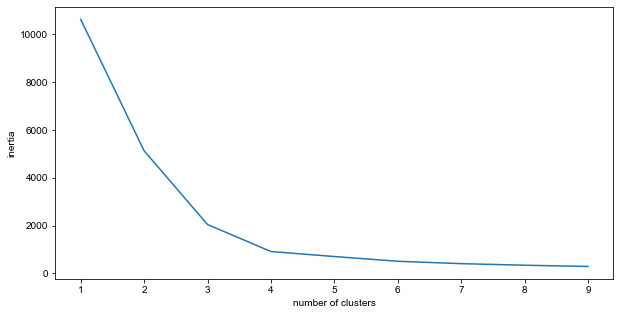

In [38]:
optimise_k_means(sigmeta_stdrow,10)

In [26]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(sigmeta_stdrow[['Con','LPS','IL_4']])

sigmeta_stdrow['kmeans']=kmeans.labels_
sigmeta_stdrow

,Con,LPS,IL_4,kmeans
mz,,,,
103.05445,-0.751163,-0.505034,1.256197,1
106.08668,-0.377902,0.952736,-0.574834,2
119.04943,-0.622104,-0.540410,1.162514,1
120.08104,-0.260240,-0.925381,1.185621,1
130.05033,-0.523595,-0.680343,1.203938,1
...,...,...,...,...
980.57307,-0.002573,0.813702,-0.811129,2
978.20677,0.503854,0.456647,-0.960501,2
989.48732,0.530082,0.683479,-1.213561,2


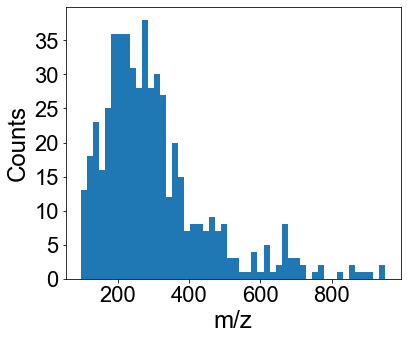

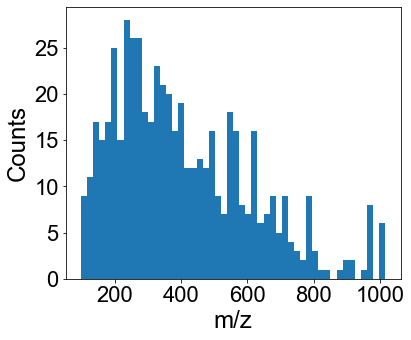

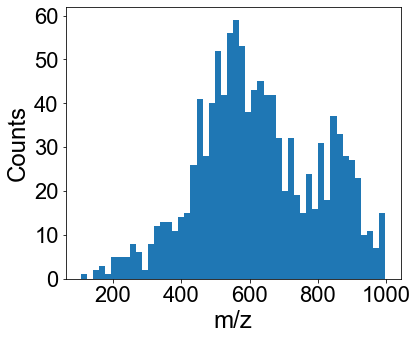

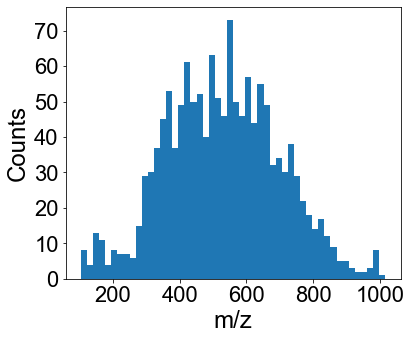

In [47]:
plt.rcParams['font.family'] = 'Arial'
for i in [0,1,2,3]:
    plt.figure(figsize=(6, 5), edgecolor='#04253a')
    plt.hist(sigmeta_stdrow[sigmeta_stdrow['kmeans']==i].index,bins=50) 
#plt.title(title, fontsize=24)
    plt.xlabel('m/z', fontsize=24)
    plt.ylabel('Counts', fontsize=24)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\{}.svg'.format(i),dpi=800,bbox_inches='tight')
    plt.show()

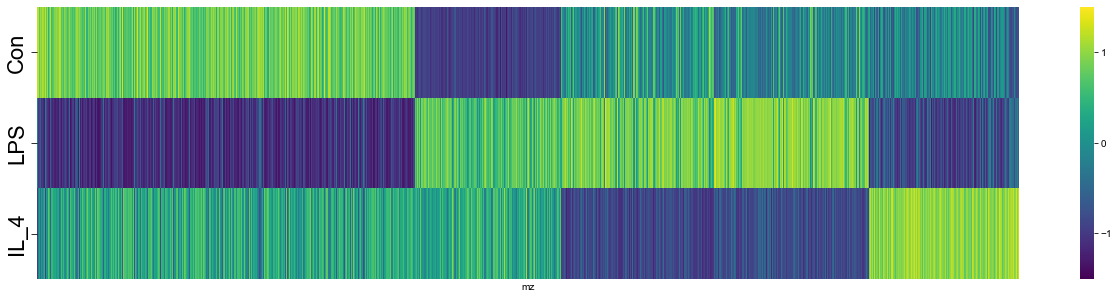

In [48]:
# plot heatmap for significant metabolites
df_df=sigmeta_stdrow
dfaa=df_df.sort_values(by='kmeans')
df_bb=dfaa.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(22,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 1, 'ticks': [-2, -1, 0, 1, 2]})
plt.xticks([])
plt.yticks()
plt.tick_params(axis='y',length=6)
plt.yticks(rotation=90)
plt.yticks(fontsize=22)
plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\sigmeta_heatmap.svg',dpi=600,bbox_inches='tight')

In [34]:
x=['Con','LPS','IL_4']

# take different cluster metatein names out
#sig_cluster4=sigmeta_stdrow.loc[sigmeta_stdrow['kmeans']==4]
sig_cluster3=sigmeta_stdrow.loc[sigmeta_stdrow['kmeans']==3]
sig_cluster2=sigmeta_stdrow.loc[sigmeta_stdrow['kmeans']==2]
sig_cluster1=sigmeta_stdrow.loc[sigmeta_stdrow['kmeans']==1]
sig_cluster0=sigmeta_stdrow.loc[sigmeta_stdrow['kmeans']==0]

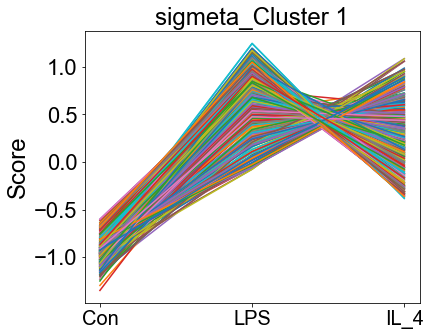

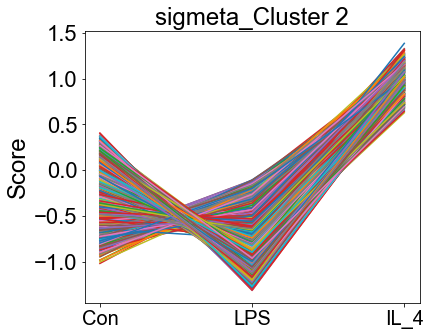

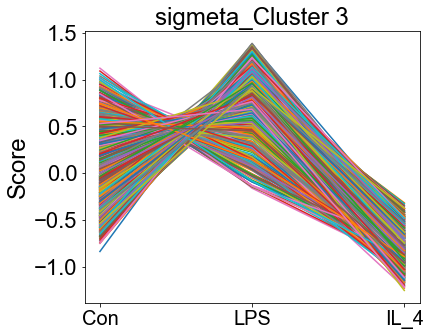

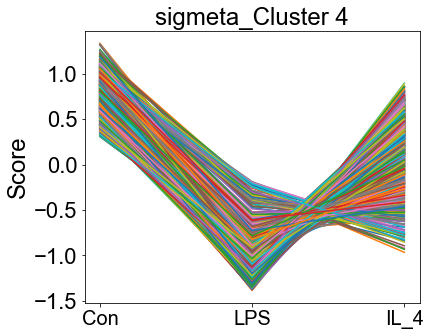

In [35]:
import matplotlib.pyplot as plt

# Create a dictionary of cluster names and corresponding data
cluster_data = {'sigmeta_Cluster 1': sigmeta_stdrow.loc[list(sig_cluster0.index)],
                'sigmeta_Cluster 2': sigmeta_stdrow.loc[list(sig_cluster1.index)],
                'sigmeta_Cluster 3': sigmeta_stdrow.loc[list(sig_cluster2.index)],
                'sigmeta_Cluster 4': sigmeta_stdrow.loc[list(sig_cluster3.index)],}
                #'Cluster 5': sigmeta_stdrow.loc[list(sig_cluster4.index)]}

# Loop over the dictionary items to plot the data for each cluster
for title, data in cluster_data.items():
    plt.figure(figsize=(6, 5), edgecolor='#04253a')
    plt.rcParams['font.family'] = 'Arial'
    for i in range(len(data)):
        plt.plot(x, data.iloc[i, :3])  
    plt.title(title, fontsize=24)
    #plt.xlabel('Treatment', fontsize=24)
    plt.ylabel('Score', fontsize=24)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=22)
    plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\{}.svg'.format(title),dpi=800,bbox_inches='tight')
    plt.show()

#Trying to match significant meta m/z to the identified m/z

In [52]:
# Trying to match significant meta m/z to the identified m/z

In [3]:
# input the identified m/z features from GNPS results 
fileslist = []
dir = 'D:\\project7_SMAD\\meta_identification'
for file in os.listdir(dir):
    if file.endswith(".tsv"):
        fileslist.append(os.path.join(dir, file))
print(fileslist)

['D:\\project7_SMAD\\meta_identification\\meta_293_macro_st.tsv', 'D:\\project7_SMAD\\meta_identification\\meta_macro_st.tsv', 'D:\\project7_SMAD\\meta_identification\\meta_293T_st.tsv', 'D:\\project7_SMAD\\meta_identification\\meta_293T.tsv', 'D:\\project7_SMAD\\meta_identification\\meta_macro.tsv', 'D:\\project7_SMAD\\meta_identification\\293_macro.tsv']


In [4]:
meta_macro=pd.read_csv(fileslist[1],delimiter="\t", header=0)
# filter the dataframe with 'MZErrorPPM' < 30 ppm

meta_macro_filter=meta_macro[meta_macro['MZErrorPPM'] < 30]

In [5]:
meta_macro_filter

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,Compound_Source,Data_Collector,ExactMass,...,class,full_CCMS_path,internalFilename,npclassifier_class,npclassifier_pathway,npclassifier_superclass,subclass,superclass,tags,id
0,1,1,408,[M+H]+,NaN,1,Massbank:PB000420 Arginine|2-amino-5-(diaminom...,Isolated,Massbank,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,0
1,2,2,914,[M+H]+,NaN,1,Glutathione,isolated,MoNA:VF-NPL-QTOF002082,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,1
2,3,3,813,[M+H]+,NaN,1,Massbank:PB000420 Arginine|2-amino-5-(diaminom...,Isolated,Massbank,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,2
3,4,4,4,M+H,NaN,1,L-(+)-Arginine - 40.0 eV,Isolated,Data Collector,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,3
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,Isolated,Data deposited by lfnothias,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,533,533,931,M+Na,NaN,1,CYTIDINE MONOPHOSPHATE,Commercial,Kelly Weldon,323.052,...,Pyrimidine nucleotides,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,Pyrimidine nucleos(t)ides,Carbohydrates,Nucleosides,Pyrimidine ribonucleotides,"Nucleosides, nucleotides, and analogues",NaN,532
533,534,534,608,M+H,13962055.0,1,Spectral Match to Oleoyl L-carnitine from NIST14,Isolated,Data deposited by mjmeehan,425.350,...,Fatty Acyls,yuming/ST_Macro_mix2_meta_DDA_Qslices_35_40_45...,spec-00001.mzXML,NaN,NaN,NaN,Fatty acid esters,Lipids and lipid-like molecules,NaN,533
534,535,535,924,332.1,95983781.0,1,Spectral Match to N-Acetylneuraminic Acid Dime...,Isolated,Data deposited by amelnik,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,534
535,536,536,421,M+H,NaN,1,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1,Commercial,Thomas Metz,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_35_40_45...,spec-00001.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,535


In [57]:
#len(remove_dul(tar_list=meta_macro_filter['Compound_Name'].tolist()))

In [9]:
# try to match the significant metabolite m/z features to the identified m/z features from GNPS

scan_20_25_30=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30.mzXML']
scan_35_40_45=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_35_40_45.mzXML']
scan_5_10_15=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15.mzXML']

In [10]:
scan_5_10_15

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,Compound_Source,Data_Collector,ExactMass,...,class,full_CCMS_path,internalFilename,npclassifier_class,npclassifier_pathway,npclassifier_superclass,subclass,superclass,tags,id
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,Isolated,Data deposited by lfnothias,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,4
5,6,6,7,M+H,NaN,1,Massbank:UA005501 L-Phenylalanine|(2S)-2-Azani...,Isolated,Massbank,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,Aminoacids,Amino acids and Peptides|Shikimates and Phenyl...,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,5
6,7,7,411,M+H,NaN,1,Histidine,Commercial,Jing-Jing Wang,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,6
14,15,15,430,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,Isolated,Data deposited by lfnothias,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,14
26,27,27,839,M+H-H2O,NaN,1,pyridoxal CollisionEnergy:205060,Commercial,JGI,0.000,...,Pyridines and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,Pyridine alkaloids,Alkaloids,Nicotinic acid alkaloids,Pyridine carboxaldehydes,Organoheterocyclic compounds,NaN,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,526,526,808,M+Na,NaN,1,Spectral Match to N-Tetracosenoyl-4-sphingenyl...,Isolated,Data deposited by alchemistmatt,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,525
529,530,530,436,M+H-H2O,60322.0,1,Spectral Match to 6-Aminocaproic acid from NIST14,Isolated,Data deposited by lfnothias,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,529
531,532,532,790,M+H,NaN,1,PC(16:0/20:5); [M+H]+ C44H79N1O8P1,Commercial,Thomas Metz,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,531
532,533,533,931,M+Na,NaN,1,CYTIDINE MONOPHOSPHATE,Commercial,Kelly Weldon,323.052,...,Pyrimidine nucleotides,yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15....,spec-00002.mzXML,Pyrimidine nucleos(t)ides,Carbohydrates,Nucleosides,Pyrimidine ribonucleotides,"Nucleosides, nucleotides, and analogues",NaN,532


In [11]:
mzmlslist = []
dir = 'D:\\yuming\\2023\\20230401\\ST_MACRO'
for file in os.listdir(dir):
    if file.endswith(".mzML") and 'Macro' in file:
        mzmlslist.append(os.path.join(dir, file))
print(mzmlslist)

['D:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_35_40_45.mzML', 'D:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_5_10_15.mzML', 'D:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_20_25_30.mzML']


In [12]:
tmp_5_10_15 = pyteomics.mzml.read(mzmlslist[1], use_index=True)
tmp_20_25_30 = pyteomics.mzml.read(mzmlslist[2], use_index=True)
tmp_35_40_45 = pyteomics.mzml.read(mzmlslist[0], use_index=True)

In [13]:
list_cv1,list_cv2,list_cv3=[],[],[]

for number in list(np.array(scan_5_10_15['#Scan#'].tolist())-1):
    list_cv1.append(float(tmp_5_10_15.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))
for number in list(np.array(scan_20_25_30['#Scan#'].tolist())-1):
    list_cv2.append(float(tmp_20_25_30.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))
for number in list(np.array(scan_35_40_45['#Scan#'].tolist())-1):
    list_cv3.append(float(tmp_35_40_45.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))

In [14]:
new_df1=scan_5_10_15.iloc[:,:7]
new_df2=scan_20_25_30.iloc[:,:7]
new_df3=scan_35_40_45.iloc[:,:7]
new_df1['mz']=list_cv1
new_df2['mz']=list_cv2
new_df3['mz']=list_cv3
newdf_all=pd.concat([new_df1,new_df2,new_df3])
newdf_all

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,mz
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602
5,6,6,7,M+H,NaN,1,Massbank:UA005501 L-Phenylalanine|(2S)-2-Azani...,166.086166
6,7,7,411,M+H,NaN,1,Histidine,156.076706
14,15,15,430,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602
26,27,27,839,M+H-H2O,NaN,1,pyridoxal CollisionEnergy:205060,150.054962
...,...,...,...,...,...,...,...,...
526,527,527,678,M+H,NaN,1,Massbank:RP025803 1-Stearoyl-sn-glycero-3-phos...,525.374146
528,529,529,660,M+H,NaN,1,PE(20:4/0:0); [M+H]+ C25H45N1O7P1,502.292328
533,534,534,608,M+H,13962055.0,1,Spectral Match to Oleoyl L-carnitine from NIST14,426.357635
535,536,536,421,M+H,NaN,1,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1,748.527222


In [15]:
newdf_all['mz_rounded']=[round(num, 3) for num in newdf_all['mz']]
newdf_all

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,mz,mz_rounded
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071
5,6,6,7,M+H,NaN,1,Massbank:UA005501 L-Phenylalanine|(2S)-2-Azani...,166.086166,166.086
6,7,7,411,M+H,NaN,1,Histidine,156.076706,156.077
14,15,15,430,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071
26,27,27,839,M+H-H2O,NaN,1,pyridoxal CollisionEnergy:205060,150.054962,150.055
...,...,...,...,...,...,...,...,...,...
526,527,527,678,M+H,NaN,1,Massbank:RP025803 1-Stearoyl-sn-glycero-3-phos...,525.374146,525.374
528,529,529,660,M+H,NaN,1,PE(20:4/0:0); [M+H]+ C25H45N1O7P1,502.292328,502.292
533,534,534,608,M+H,13962055.0,1,Spectral Match to Oleoyl L-carnitine from NIST14,426.357635,426.358
535,536,536,421,M+H,NaN,1,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1,748.527222,748.527


In [16]:
newdf_all.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\GNPS_RESULTS.xlsx')

In [65]:
mz=[round(x, 3) for x in dfmeta_sig.index.tolist()]

dfmeta_sig2=dfmeta_sig
dfmeta_sig2['mz_rounded']=mz
dfmeta_sig2

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6,mz_rounded
mz,,,,,,,,,,,,,,,,,,,
103.05445,0.782094,0.717248,0.905932,0.899586,0.781438,1.016370,0.818617,0.902179,0.963046,0.873753,0.920600,0.901648,1.021947,1.226739,1.323378,1.267207,1.270069,1.253887,103.054
106.08668,0.370745,0.176076,0.432105,0.875089,0.296394,0.736004,0.896122,1.114649,0.905733,0.552637,0.717490,0.743570,0.269378,0.314319,0.599810,0.428498,0.406611,0.565321,106.087
119.04943,-0.026074,-0.184928,0.115929,0.015827,-0.080576,0.205948,-0.071661,0.055721,0.164431,-0.111765,0.091589,0.015024,0.130627,0.350165,0.497803,0.439298,0.364787,0.387084,119.049
120.08104,2.738846,2.726829,3.012589,3.056203,2.858276,3.130372,2.609899,2.676170,2.759674,2.768546,2.832667,2.771823,3.055500,3.188355,3.459820,3.425230,3.375049,3.419726,120.081
130.05033,0.372748,0.340515,0.439162,0.348682,0.367323,0.503167,0.318634,0.428220,0.486006,0.281611,0.338479,0.392012,0.487941,0.709779,0.562321,0.720723,0.650882,0.635601,130.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980.57307,-0.540794,0.068793,-0.493770,0.143316,-0.877260,0.321157,0.240607,0.538704,0.186697,-0.036247,0.212583,0.260149,-0.526467,-0.238647,-0.007495,-1.713561,-1.126549,-0.520591,980.573
978.20677,-0.420587,0.078165,-0.039369,-0.674252,-1.441569,-0.379580,-0.204126,0.124204,-0.306431,-1.071373,-0.636381,-0.954486,-0.762544,-2.002944,-1.315312,-1.455454,-1.658822,-0.998910,978.207
989.48732,0.252874,0.625047,0.500504,0.367871,0.311814,0.420047,0.757731,0.765610,0.395999,0.067211,0.398204,0.417531,-0.003857,-0.061141,-0.148898,-0.455903,-0.332682,-0.203728,989.487


In [66]:
# get the significant m/z and corresponding compound name out  named the dataframe to name_df

name_df=dfmeta_sig2[dfmeta_sig2['mz_rounded'].isin (newdf_all['mz_rounded'].tolist())]


In [130]:
name_df.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_sigmeta_identified_63.xlsx')
name_df

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6,mz_rounded
mz,,,,,,,,,,,,,,,,,,,
120.08104,2.738846,2.726829,3.012589,3.056203,2.858276,3.130372,2.609899,2.676170,2.759674,2.768546,2.832667,2.771823,3.055500,3.188355,3.459820,3.425230,3.375049,3.419726,120.081
132.07695,3.873663,3.971717,4.045915,4.175057,3.969287,4.038558,3.210362,3.243586,3.565978,3.647151,3.594903,3.483929,4.061887,4.136551,4.203854,4.407683,4.126045,4.411697,132.077
104.10670,4.631021,4.784596,4.895374,4.746276,4.650551,4.737552,3.701858,3.843993,4.129629,4.292166,4.136266,3.931766,4.360404,4.558974,4.579169,4.773507,4.636582,4.840958,104.107
129.13852,2.980257,2.709774,2.636335,2.606021,2.719349,2.710626,2.239107,2.264303,2.432157,2.115625,2.089311,2.010183,2.881609,3.068302,2.623219,2.872793,2.497246,2.937916,129.139
137.13241,-0.469246,-0.233817,-0.541059,-0.365829,-0.121817,-0.372893,0.262506,-0.037941,0.052265,0.437988,0.502755,0.388913,0.067385,-0.041835,0.509190,0.137845,0.536371,-0.297800,137.132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796.58281,3.142400,3.146834,3.183915,3.136970,3.207766,2.956427,3.183572,3.220142,3.211415,3.238628,3.218118,3.164731,3.027419,2.935674,2.958539,3.031781,3.016027,3.016777,796.583
810.59830,4.522271,4.481319,4.678389,4.717103,4.646886,4.439911,4.265136,4.231865,4.347346,4.514151,4.402992,4.353313,4.512313,4.369036,4.428088,4.556513,4.515931,4.473973,810.598
813.68401,3.790294,4.057338,4.142502,4.250538,4.186675,4.006274,3.642978,3.689454,3.792487,4.100930,3.992996,3.836424,4.319282,4.092996,4.093517,4.334456,4.256609,4.128249,813.684


In [517]:
#name_df2=newdf_all[newdf_all['mz_rounded'].isin (name_df['mz_rounded'].tolist())]

In [508]:
#name_df.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\sig_meta_identified.xlsx')

In [68]:
dfmeta_id=pd.read_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\sig_meta_identified.xlsx')

In [69]:
dfmeta_id.set_index('mz_rounded',inplace=True)

In [70]:
dfmeta_id=dfmeta_id.iloc[:,1:]
dfmeta_id

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz_rounded,,,,,,,,,,,,,,,,,,
120.081,2.738846,2.726829,3.012589,3.056203,2.858276,3.130372,2.609899,2.676170,2.759674,2.768546,2.832667,2.771823,3.055500,3.188355,3.459820,3.425230,3.375049,3.419726
132.077,3.873663,3.971717,4.045915,4.175057,3.969287,4.038558,3.210362,3.243586,3.565978,3.647151,3.594903,3.483929,4.061887,4.136551,4.203854,4.407683,4.126045,4.411697
104.107,4.631021,4.784596,4.895374,4.746276,4.650551,4.737552,3.701858,3.843993,4.129629,4.292166,4.136266,3.931766,4.360404,4.558974,4.579169,4.773507,4.636582,4.840958
129.139,2.980257,2.709774,2.636335,2.606021,2.719349,2.710626,2.239107,2.264303,2.432157,2.115625,2.089311,2.010183,2.881609,3.068302,2.623219,2.872793,2.497246,2.937916
137.132,-0.469246,-0.233817,-0.541059,-0.365829,-0.121817,-0.372893,0.262506,-0.037941,0.052265,0.437988,0.502755,0.388913,0.067385,-0.041835,0.509190,0.137845,0.536371,-0.297800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796.583,3.142400,3.146834,3.183915,3.136970,3.207766,2.956427,3.183572,3.220142,3.211415,3.238628,3.218118,3.164731,3.027419,2.935674,2.958539,3.031781,3.016027,3.016777
810.598,4.522271,4.481319,4.678389,4.717103,4.646886,4.439911,4.265136,4.231865,4.347346,4.514151,4.402992,4.353313,4.512313,4.369036,4.428088,4.556513,4.515931,4.473973
813.684,3.790294,4.057338,4.142502,4.250538,4.186675,4.006274,3.642978,3.689454,3.792487,4.100930,3.992996,3.836424,4.319282,4.092996,4.093517,4.334456,4.256609,4.128249


In [71]:
# K means clustering of the identifed and significat metabolite features 
# 按行进行标准归一化
sss=StandardScaler()
anyte=dfmeta_id.T.columns
er=dfmeta_id.T
dfer=ss.fit_transform(er)
# 按行进行标准化后的 dataframe
dfer_stdbyrow=pd.DataFrame(dfer.T,index=dfmeta_id.index,columns=dfmeta_id.columns)
dfer_stdbyrow


,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,C1,C2,C3,C4,C5,C6
mz_rounded,,,,,,,,,,,,,,,,,,
120.081,-0.916769,-0.960197,0.072481,0.230094,-0.485174,0.498127,-1.382758,-1.143267,-0.841502,-0.809442,-0.577718,-0.797599,0.227554,0.707664,1.688688,1.563685,1.382340,1.543793
132.077,-0.069902,0.209299,0.420573,0.788295,0.202380,0.399624,-1.958605,-1.864000,-0.946014,-0.714880,-0.863651,-1.179642,0.466053,0.678651,0.870293,1.450681,0.648738,1.462109
104.107,0.485765,0.915092,1.224777,0.807965,0.540360,0.783578,-2.111760,-1.714413,-0.915902,-0.461524,-0.897349,-1.469040,-0.270761,0.284351,0.340808,0.884090,0.501310,1.072654
129.139,1.278027,0.419834,0.186826,0.090645,0.450214,0.422538,-1.073509,-0.993566,-0.460994,-1.465292,-1.548783,-1.799841,0.965037,1.557380,0.145212,0.937065,-0.254480,1.143687
137.132,-1.415685,-0.738520,-1.622240,-1.118226,-0.416374,-1.138544,0.689053,-0.175120,0.084337,1.193793,1.380081,1.052639,0.127827,-0.186323,1.398591,0.330492,1.476771,-0.922553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796.583,0.310559,0.354351,0.720540,0.256933,0.956076,-1.525990,0.717153,1.078291,0.992108,1.260844,1.058305,0.531083,-0.824913,-1.730929,-1.505131,-0.781843,-0.937423,-0.930013
810.598,0.408656,0.089667,1.624717,1.926269,1.379328,-0.232874,-1.594261,-1.853417,-0.953899,0.345405,-0.520451,-0.907420,0.331093,-0.784947,-0.324966,0.675380,0.359274,0.032447
813.684,-1.218139,0.086322,0.502331,1.030070,0.718108,-0.163116,-1.937751,-1.710724,-1.207429,0.299259,-0.227978,-0.992805,1.365869,0.260506,0.263051,1.439994,1.059723,0.432708


In [72]:
#calculate the mean value of identified metabolites of 6 repeats for each treatment, socurce dataframe is after two times std_scaler 
con2=dfer_stdbyrow.iloc[:,:6].mean(axis=1).tolist()
lps2=dfer_stdbyrow.iloc[:,6:12].mean(axis=1).tolist()
IL_42=dfer_stdbyrow.iloc[:,12:18].mean(axis=1).tolist()
newdict2={'Con':con2,'LPS':lps2,'IL_4':IL_42}

dfer_mean=pd.DataFrame.from_dict(newdict2)
dfer_mean.index=dfer_stdbyrow.index
dfer_mean

,Con,LPS,IL_4
mz_rounded,,,
120.081,-0.260240,-0.925381,1.185621
132.077,0.325045,-1.254466,0.929421
104.107,0.792923,-1.261665,0.468742
129.139,0.474681,-1.223664,0.748984
137.132,-1.074931,0.704131,0.370801
...,...,...,...
796.583,0.178745,0.939631,-1.118376
810.598,0.865960,-0.914007,0.048047
813.684,0.159263,-0.962905,0.803642


In [73]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(dfer_mean[['Con','LPS','IL_4']])

dfer_mean['kmeans']=kmeans.labels_
dfer_mean

,Con,LPS,IL_4,kmeans
mz_rounded,,,,
120.081,-0.260240,-0.925381,1.185621,1
132.077,0.325045,-1.254466,0.929421,3
104.107,0.792923,-1.261665,0.468742,3
129.139,0.474681,-1.223664,0.748984,3
137.132,-1.074931,0.704131,0.370801,2
...,...,...,...,...
796.583,0.178745,0.939631,-1.118376,2
810.598,0.865960,-0.914007,0.048047,0
813.684,0.159263,-0.962905,0.803642,3


In [74]:
sigpro_stdrow

,Con,LPS,IL_4,kmeans
Unnamed: 0,,,,
2/tr|Q6PHC1|Q6PHC1_MOUSE/sp|P17182|ENOA_MOUSE,0.995731,-0.970401,-0.025330,0
9/tr|G5E846|G5E846_MOUSE/tr|G3X981|G3X981_MOUSE/tr|A0A2R8W6R6|A0A2R8W6R6_MOUSE/tr|A0A0A6YWC8|A0A0A6YWC8_MOUSE/sp|Q9DCV7|K2C7_MOUSE/sp|P31001|DESM_MOUSE/sp|P20152|VIME_MOUSE/sp|P15331|PERI_MOUSE/sp|P11679|K2C8_MOUSE,-0.845362,1.006575,-0.161213,1
2/tr|Q8BG13|Q8BG13_MOUSE/sp|O89086|RBM3_MOUSE,-0.579152,1.040851,-0.461699,1
1/sp|Q9DBJ1|PGAM1_MOUSE,0.794994,-0.921173,0.126179,0
2/tr|B8JKK2|B8JKK2_MOUSE/sp|Q9CZM2|RL15_MOUSE,-1.037064,0.956212,0.080852,3
...,...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694,0
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966,0
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983,1


In [75]:
sample=[2,4,6,8,3]
def remove_dul(tar_list=sample):
    res=[]
    [res.append(x) for x in tar_list if x not in res]
    return(res)

def plot_clusters(df=sigmeta_stdrow):
    x=['Con','LPS','IL_4']
    # take different cluster metatein names out
    #sig_cluster4=df.loc[df['kmeans']==4]
    sig_cluster3=df.loc[df['kmeans']==3]
    sig_cluster2=df.loc[df['kmeans']==2]
    sig_cluster1=df.loc[df['kmeans']==1]
    sig_cluster0=df.loc[df['kmeans']==0]
    # Create a dictionary of cluster names and corresponding data
    cluster_data = {'Cluster 1': df.loc[list(sig_cluster0.index)],
                    'Cluster 2': df.loc[list(sig_cluster1.index)],
                    'Cluster 3': df.loc[list(sig_cluster2.index)],
                    'Cluster 4': df.loc[list(sig_cluster3.index)],}
                    #'Cluster 5': df.loc[list(sig_cluster4.index)]}

    # Loop over the dictionary items to plot the data for each cluster
    for title, data in cluster_data.items():
        plt.figure(figsize=(6, 5), edgecolor='#04253a')
        plt.rcParams['font.family'] = 'Arial'
        for i in range(len(data)):
            plt.plot(x, data.iloc[i, :3])  
        plt.title(title, fontsize=24)
        plt.xlabel('Treatment', fontsize=24)
        plt.ylabel('Score', fontsize=24)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=22)
        plt.show()

In [76]:
#plot_clusters(df=dfer_mean)

In [96]:
# combine significant proteins and identified metabolites together
result = pd.concat([dfer_mean, sigpro_stdrow], axis=0)
result=result.iloc[:,:3]
result

,Con,LPS,IL_4
120.081,-0.260240,-0.925381,1.185621
132.077,0.325045,-1.254466,0.929421
104.107,0.792923,-1.261665,0.468742
129.139,0.474681,-1.223664,0.748984
137.132,-1.074931,0.704131,0.370801
...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983
2/tr|A0A286YEB7|A0A286YEB7_MOUSE/sp|P62849|RS24_MOUSE,-1.071311,0.684313,0.386998


In [97]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(result[['Con','LPS','IL_4']])

result['kmeans']=kmeans.labels_
result

,Con,LPS,IL_4,kmeans
120.081,-0.260240,-0.925381,1.185621,0
132.077,0.325045,-1.254466,0.929421,0
104.107,0.792923,-1.261665,0.468742,3
129.139,0.474681,-1.223664,0.748984,0
137.132,-1.074931,0.704131,0.370801,2
...,...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694,3
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966,3
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983,1
2/tr|A0A286YEB7|A0A286YEB7_MOUSE/sp|P62849|RS24_MOUSE,-1.071311,0.684313,0.386998,2


In [111]:
#result.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\sig_multi_identified_dropdulpli_final.xlsx')

In [15]:
result2=pd.read_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\sig_multi_identified_dropdulpli_final.xlsx',index_col=0)

In [16]:
result2

,Con,LPS,IL_4,kmeans
120.081,-0.260240,-0.925381,1.185621,0
132.077,0.325045,-1.254466,0.929421,0
104.107,0.792923,-1.261665,0.468742,3
129.139,0.474681,-1.223664,0.748984,0
137.132,-1.074931,0.704131,0.370801,2
...,...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694,3
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966,3
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983,1
2/tr|A0A286YEB7|A0A286YEB7_MOUSE/sp|P62849|RS24_MOUSE,-1.071311,0.684313,0.386998,2


In [17]:
result3=result2.iloc[:,:3]

In [18]:
result3

,Con,LPS,IL_4
120.081,-0.260240,-0.925381,1.185621
132.077,0.325045,-1.254466,0.929421
104.107,0.792923,-1.261665,0.468742
129.139,0.474681,-1.223664,0.748984
137.132,-1.074931,0.704131,0.370801
...,...,...,...
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694
1/sp|P40142|TKT_MOUSE,0.735751,-1.220717,0.484966
1/sp|Q8K1T1|LRC25_MOUSE,-0.923642,1.129624,-0.205983
2/tr|A0A286YEB7|A0A286YEB7_MOUSE/sp|P62849|RS24_MOUSE,-1.071311,0.684313,0.386998


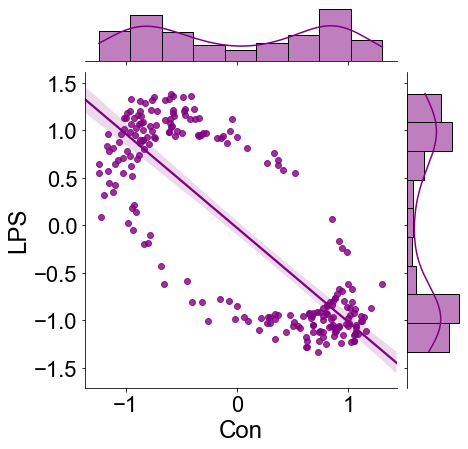

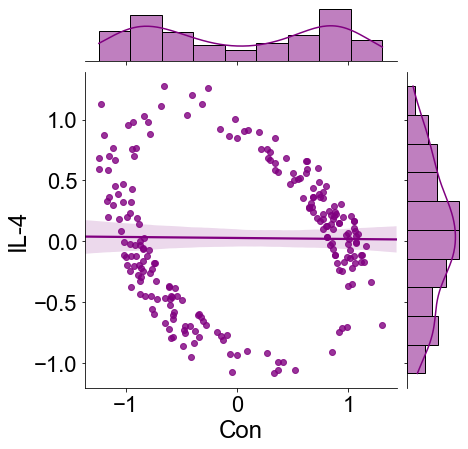

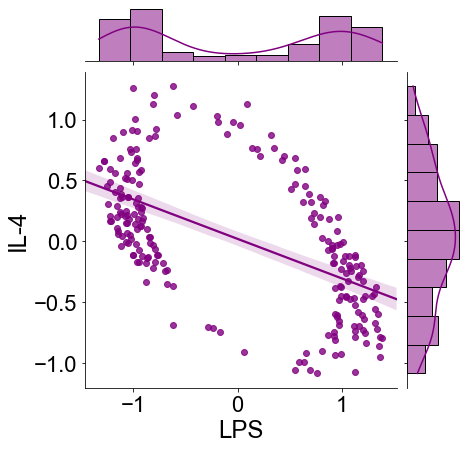

In [37]:
df=sigpro_stdrow

plt.rcParams['font.family'] = 'Arial'
g1=sns.jointplot(x=df.Con, 
                  y=df.LPS,
                  #xlim = (13,26), ylim = (13,26),
                  kind="reg", truncate=False,
                  color="purple", height=6)
g1.ax_joint.tick_params(labelsize=22)
g1.set_axis_labels("Con", "LPS", fontsize=24)
#plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\metaG1.svg',dpi=800,bbox_inches='tight')
g2=sns.jointplot(x=df.Con, 
                  y=df.IL_4,
                  #xlim = (13,26), ylim = (13,26),
                  kind="reg", truncate=False,
                  color="purple", height=6)
g2.ax_joint.tick_params(labelsize=22)
g2.set_axis_labels("Con", "IL-4", fontsize=24)
#plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\metaG2.svg',dpi=800,bbox_inches='tight')
g3=sns.jointplot(x=df.LPS, 
                  y=df.IL_4,
                  #xlim = (13,26), ylim = (13,26),
                  kind="reg", truncate=False,
                  color="purple", height=6)
g3.ax_joint.tick_params(labelsize=22)
g3.set_axis_labels("LPS", "IL-4", fontsize=24)
#plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\metaG3.svg',dpi=800,bbox_inches='tight')

[32, 32]


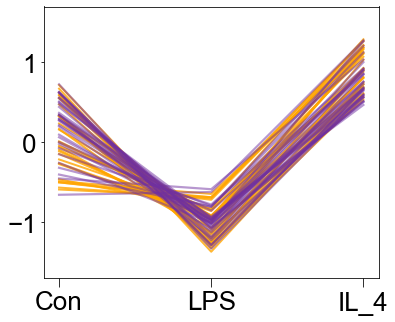

[5, 81]


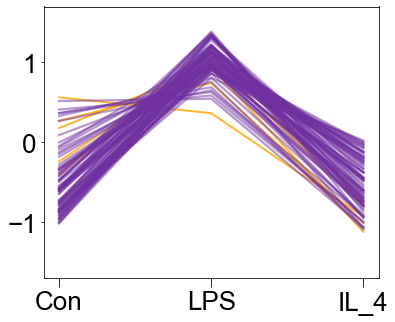

[5, 33]


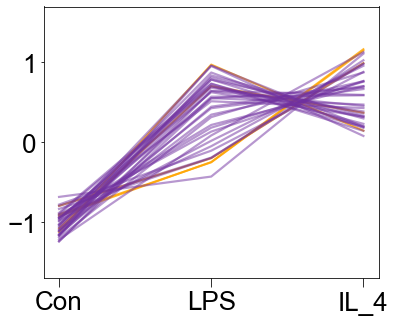

[19, 78]


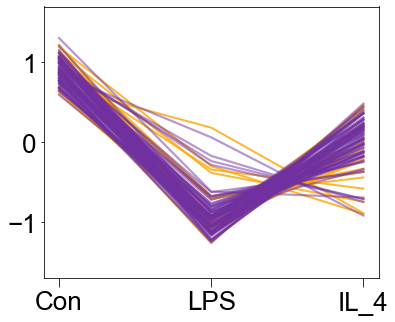

In [132]:
sig_cluster3=result2.loc[result2['kmeans']==3]
sig_cluster2=result2.loc[result2['kmeans']==2]
sig_cluster1=result2.loc[result2['kmeans']==1]
sig_cluster0=result2.loc[result2['kmeans']==0]

# Create a dictionary of cluster names and corresponding data
cluster_data = {'multiCluster 1': result3.loc[list(sig_cluster0.index)],
                'multiCluster 2': result3.loc[list(sig_cluster1.index)],
                'multiCluster 3': result3.loc[list(sig_cluster2.index)],
                'multiCluster 4': result3.loc[list(sig_cluster3.index)]}
x=['Con','LPS','IL_4']
# Loop over the dictionary items to plot the data for each cluster
for title, data in cluster_data.items():
    plt.figure(figsize=(6, 5), edgecolor='#04253a')
    plt.rcParams['font.family'] = 'Arial'
    num1,num2=[],[]
    for index in data.index:
        if isinstance(index, float):
            plt.plot(x,list(data.loc[index]),color="#FFA500",alpha=0.8,linewidth=2,label='metabolites')
            num1.append(index)
        if isinstance(index, str):
            plt.plot(x,list(data.loc[index]),color="#7030A0",alpha=0.5,linewidth=2.2,label='proteins') 
            num2.append(index)
    print([len(num1),len(num2)])
    #plt.title(title, fontsize=24)
    #plt.xlabel('Treatment', fontsize=24)
    #plt.ylabel('Score', fontsize=24)
    plt.xticks(fontsize=26)
    plt.yticks(fontsize=26)
    plt.ylim(-1.7,1.7)
    plt.yticks([-1,  0,  1])
    plt.tick_params(axis='x', which='both', length=9)
    plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\{}.svg'.format(title))
    plt.show()

In [3]:
# plot the heatmap for multiomic dataset

df=pd.read_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\sig_multi_identified_dropdulpli_final.xlsx',index_col=0,sheet_name="Sheet2")


In [4]:
df

,Con,LPS,IL_4,kmeans
120.081,-0.260240,-0.925381,1.185621,0
132.077,0.325045,-1.254466,0.929421,0
129.139,0.474681,-1.223664,0.748984,0
165.055,-0.271110,-0.939910,1.211020,0
150.055,0.593442,-1.323423,0.729981,0
...,...,...,...,...
1/sp|Q02105|C1QC_MOUSE,0.767615,-0.951714,0.184099,3
7/tr|Q8CDM9|Q8CDM9_MOUSE/tr|E9PUM4|E9PUM4_MOUSE/tr|A0A1L1SRI1|A0A1L1SRI1_MOUSE/tr|A0A1L1SQP9|A0A1L1SQP9_MOUSE/tr|A0A1L1SQ51|A0A1L1SQ51_MOUSE/sp|Q71LX4|TLN2_MOUSE/sp|P26039|TLN1_MOUSE,0.914887,-0.168360,-0.746527,3
1/sp|P18760|COF1_MOUSE,0.995472,-1.060290,0.064818,3
2/tr|H7BXC3|H7BXC3_MOUSE/sp|P17751|TPIS_MOUSE,0.951911,-1.154606,0.202694,3


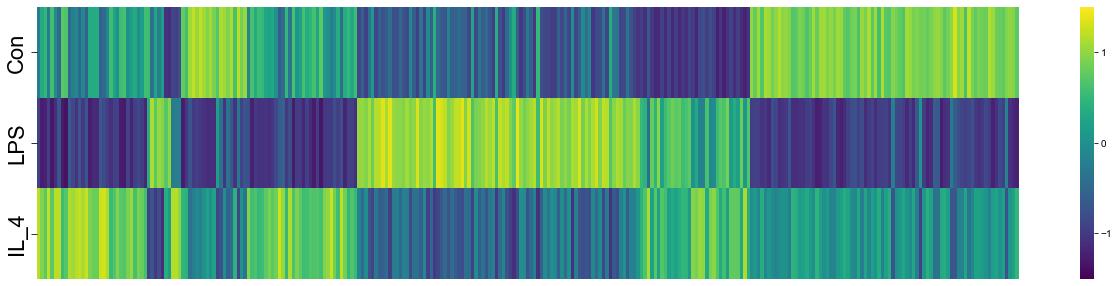

In [6]:
df_bb=df.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(22,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 1, 'ticks': [-2, -1, 0, 1, 2]})
plt.xticks([])
plt.yticks()
plt.tick_params(axis='y',length=6)
plt.yticks(rotation=90)
plt.yticks(fontsize=22)
plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\Figure3_heatmap.svg',dpi=1000)

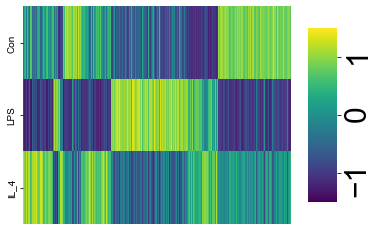

In [137]:
ax = sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 0.8, 'aspect':6,'ticks': [ -1, 0, 1]})

cbar = ax.collections[0].colorbar

# Set the font size of the colorbar tick labels
cbar.ax.tick_params(labelsize=30, rotation=90)

plt.show()

In [ ]:
df_bb=df.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(22,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 1, 'ticks': [-2, -1, 0, 1, 2]})
plt.xticks([])
plt.yticks()
plt.tick_params(axis='y',length=6)
plt.yticks(rotation=90)
plt.yticks(fontsize=22)
#plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\Figure3_heatmap.tiff',dpi=600)

# plot typical metabolites and proteins here

In [119]:
treatment=['Con']*6+['LPS']*6+['IL-4']*6

def getdf(name='2/tr|A8XU21|A8XU21_MOUSE/sp|P97369|NCF4_MOUSE',df=dfpro_stdbyrow):    
    A=df.iloc[:,:6].loc[name].to_frame()
    A.columns=['Value']  
    B=df.iloc[:,6:12].loc[name].to_frame()
    B.columns=['Value']   
    C=df.iloc[:,12:18].loc[name].to_frame()
    C.columns=['Value'] 
    made=pd.concat([A,B,C])
    made['treatment'] = treatment
    return(made)

def plot_fig(listname=['proname'],df_name=dfpro_stdbyrow):
    for number in listname:
        plt.figure(figsize=(7,7))
        dataset=getdf(name=number,df=df_name)
        #palette = ['#9B3A4D', '#E2AE79', '#497EB2','#D0DCAA', '#8CBDA7', '#68AC57','#70A0AC']
        ax = sns.boxplot(x="treatment", y="Value",width=0.8, data=dataset,palette='viridis')
        ax = sns.stripplot(x="treatment", y="Value", data=dataset, color="black",size=12)
        ax.set_xlabel("")
        ax.set_ylabel("Score", fontsize=36)
        ax.tick_params(axis='both', labelsize=35)
        ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
        plt.title(number)
        plt.show()

In [129]:
for item in dfpro_stdbyrow.index:
    if 'CMPK2' in item or 'RSAD2' in item or 'DDX58' in item or 'DHX58' in item:
        print(item)

2/tr|A2AP29|A2AP29_MOUSE/sp|Q6Q899|DDX58_MOUSE


In [134]:
for item in dfpro_stdbyrow.index:
    if 'MC' in item:
        print(item)

In [120]:
prolist=['1/sp|P56480|ATPB_MOUSE','2/tr|A2AP29|A2AP29_MOUSE/sp|Q6Q899|DDX58_MOUSE']



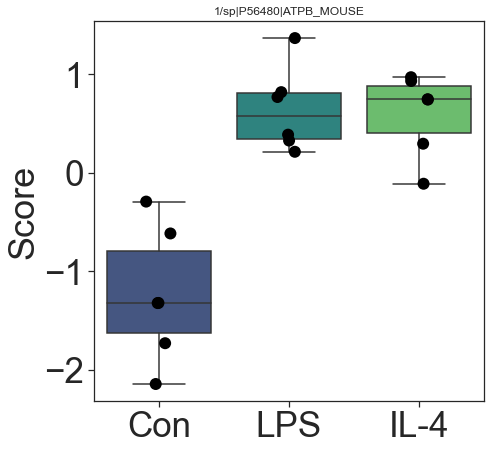

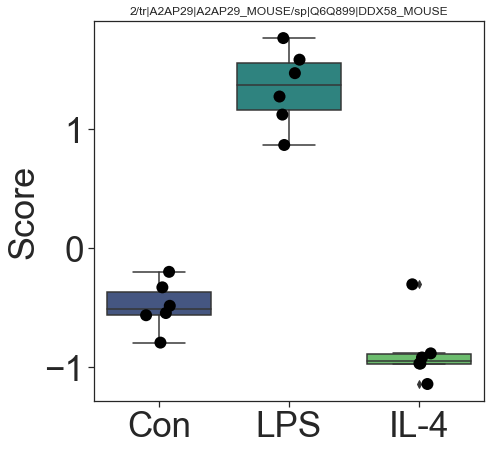

In [121]:
plot_fig(listname=prolist,df_name=dfpro_stdbyrow)

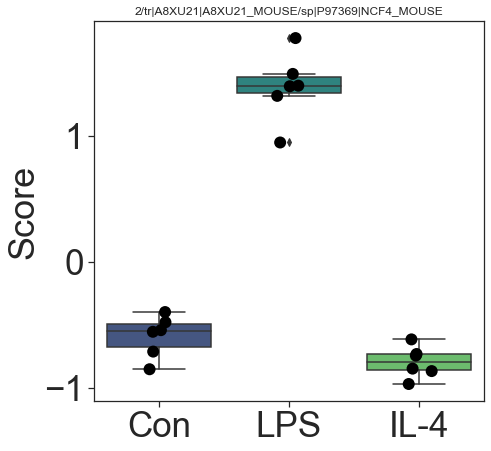

In [122]:
plot_fig(listname=['2/tr|A8XU21|A8XU21_MOUSE/sp|P97369|NCF4_MOUSE'],df_name=dfpro_stdbyrow)

In [ ]:
getdf(proname='2/tr|A8XU21|A8XU21_MOUSE/sp|P97369|NCF4_MOUSE',df=dfpro_stdbyrow)dfer_stdbyrow